<a href="https://colab.research.google.com/github/borhanur-rahman/Dengu_Biomarker_Discovery/blob/main/condition_specific_biomarkars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

# ============================================================
# CELL 2: Install packages (FIXED)
# ============================================================
!pip install -q pandas numpy scikit-learn matplotlib seaborn
!pip install -q scipy statsmodels adjustText
!pip install -q pycombat   # ← CORRECT package name

import warnings
warnings.filterwarnings('ignore')

print("All packages installed ✅")
BASE_PATH = "/content/drive/MyDrive/compendium_output"



All packages installed ✅


In [3]:
# ============================================================
# CELL 3: Load compendium data
# ============================================================
import os
import pandas as pd
import numpy as np

# Load ML-ready count matrix
counts = pd.read_csv(
    os.path.join(BASE_PATH, "compendium_ml_raw_counts.csv"),
    index_col=0
)

# Load metadata
meta = pd.read_csv(
    os.path.join(BASE_PATH, "compendium_metadata.csv"),
    index_col=0
)

print(f"Counts shape: {counts.shape}")
print(f"  Genes: {counts.shape[0]}")
print(f"  Samples: {counts.shape[1]}")
print(f"\nMetadata shape: {meta.shape}")
print(f"\nFirst 5 genes: {counts.index[:5].tolist()}")
print(f"First 5 samples: {counts.columns[:5].tolist()}")
print(f"\nMetadata columns: {meta.columns.tolist()[:15]}")

Counts shape: (28035, 1020)
  Genes: 28035
  Samples: 1020

Metadata shape: (1020, 58)

First 5 genes: ['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A2MP1']
First 5 samples: ['GSE152075_GSM4602241', 'GSE152075_GSM4602242', 'GSE152075_GSM4602243', 'GSE152075_GSM4602244', 'GSE152075_GSM4602245']

Metadata columns: ['title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'characteristics_ch1', 'characteristics_ch1_2', 'characteristics_ch1_3', 'characteristics_ch1_4', 'characteristics_ch1_5', 'molecule_ch1']


In [4]:
# ============================================================
# CELL 4: Create unified condition labels
# ============================================================

def get_condition(row):
    """Assign detailed condition label based on metadata fields."""
    disease = str(row.get("disease", ""))

    # COVID19
    if disease == "COVID19":
        inf = str(row.get("infection_status", "")).strip().lower()
        if inf == "pos":
            return "COVID19_Positive"
        elif inf == "neg":
            return "COVID19_Negative"
        return "COVID19_Unknown"

    # Diabetes
    if disease == "Diabetes":
        ds = str(row.get("diabetes_status", "")).strip()
        if ds == "T2D":
            return "Diabetes_T2D"
        elif ds == "T3cD":
            return "Diabetes_T3cD"
        elif ds == "IGT":
            return "Prediabetes_IGT"
        elif ds == "IFG":
            return "Prediabetes_IFG"
        elif ds == "ND":
            return "No_Diabetes_Control"
        return "Diabetes_Unknown"

    # Sepsis
    if disease == "Sepsis":
        ds = str(row.get("disease_state", "")).strip().lower()
        if "sepsis" in ds:
            return "Sepsis_Case"
        elif "healthy" in ds:
            return "Healthy_Control"
        return "Sepsis_Unknown"

    # Dengue
    if disease == "Dengue":
        ds = str(row.get("disease_state", "")).strip().lower()
        if "hemorrhagic" in ds or "dhf" in ds:
            return "Dengue_DHF"
        elif "dengue fever" in ds or "df" in ds:
            return "Dengue_DF"
        return "Dengue_Unknown"

    return "Unknown"


def get_binary_label(condition):
    """Convert detailed condition to Case/Control."""
    c = str(condition).lower()
    if any(x in c for x in ["control", "negative", "healthy", "no_diabetes"]):
        return "Control"
    elif "unknown" in c:
        return "Unknown"
    return "Case"


meta["condition"] = meta.apply(get_condition, axis=1)
meta["case_control"] = meta["condition"].map(get_binary_label)

print("Disease breakdown:")
print(meta["disease"].value_counts())
print("\nDetailed condition breakdown:")
print(meta["condition"].value_counts())
print("\nCase vs Control:")
print(meta["case_control"].value_counts())

Disease breakdown:
disease
COVID19     484
Sepsis      392
Diabetes    133
Dengue       11
Name: count, dtype: int64

Detailed condition breakdown:
condition
COVID19_Positive       430
Sepsis_Case            348
COVID19_Negative        54
Healthy_Control         44
Diabetes_T2D            39
Prediabetes_IGT         38
Diabetes_T3cD           35
No_Diabetes_Control     18
Dengue_DHF               6
Dengue_DF                5
Prediabetes_IFG          3
Name: count, dtype: int64

Case vs Control:
case_control
Case       904
Control    116
Name: count, dtype: int64


In [5]:
# ============================================================
# CELL 5: Normalize counts → log2(CPM + 1)
# ============================================================

def log2_cpm_normalize(counts_df):
    """Convert raw counts to log2(CPM + 1)."""
    lib_sizes = counts_df.sum(axis=0)
    cpm = counts_df.div(lib_sizes, axis=1) * 1e6
    log_cpm = np.log2(cpm + 1)
    return log_cpm

expr = log2_cpm_normalize(counts)

print(f"Normalized expression shape: {expr.shape}")
print(f"Value range: [{expr.min().min():.2f}, {expr.max().max():.2f}]")
print(f"Mean expression: {expr.mean().mean():.2f}")

Normalized expression shape: (28035, 1020)
Value range: [0.00, 18.04]
Mean expression: 1.80


In [6]:
# ============================================================
# CELL 6: Filter lowly expressed genes
# ============================================================

# Keep genes expressed (log2CPM > 1) in at least 10% of samples
min_samples = int(0.10 * expr.shape[1])
gene_mask = (expr > 1).sum(axis=1) >= min_samples

expr_filtered = expr.loc[gene_mask]

print(f"Before filtering: {expr.shape[0]:,} genes")
print(f"After filtering:  {expr_filtered.shape[0]:,} genes")
print(f"Removed:          {expr.shape[0] - expr_filtered.shape[0]:,} genes")

Before filtering: 28,035 genes
After filtering:  16,523 genes
Removed:          11,512 genes


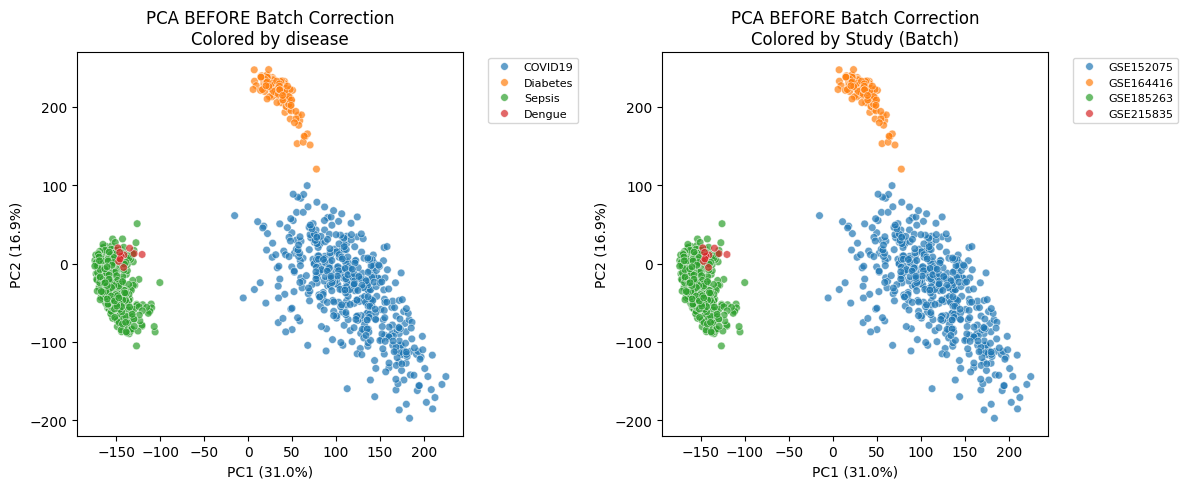

In [7]:
# ============================================================
# CELL 7: PCA visualization BEFORE batch correction
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def plot_pca(data, meta_df, color_col, title, figsize=(12, 5)):
    """Plot PCA colored by a metadata column."""
    X = data.T.values  # samples × genes

    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(X)

    pca_df = pd.DataFrame({
        'PC1': pcs[:, 0],
        'PC2': pcs[:, 1],
        color_col: meta_df.reindex(data.columns)[color_col].values
    })

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # By color_col
    sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=color_col,
                    alpha=0.7, s=30, ax=axes[0])
    axes[0].set_title(f'{title}\nColored by {color_col}')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    # By GSE (batch)
    pca_df['GSE'] = meta_df.reindex(data.columns)['gse'].values
    sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='GSE',
                    alpha=0.7, s=30, ax=axes[1])
    axes[1].set_title(f'{title}\nColored by Study (Batch)')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    ev1 = pca.explained_variance_ratio_[0] * 100
    ev2 = pca.explained_variance_ratio_[1] * 100
    axes[0].set_xlabel(f'PC1 ({ev1:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({ev2:.1f}%)')
    axes[1].set_xlabel(f'PC1 ({ev1:.1f}%)')
    axes[1].set_ylabel(f'PC2 ({ev2:.1f}%)')

    plt.tight_layout()
    plt.show()

plot_pca(expr_filtered, meta, 'disease', 'PCA BEFORE Batch Correction')

In [8]:
# ============================================================
# CELL 8: Batch correction using ComBat (FIXED)
# ============================================================

pycombat_func = None

# Method 1: pycombat.pycombat.pycombat (nested)
try:
    from pycombat.pycombat import pycombat as _pycombat
    pycombat_func = _pycombat
    print("Loaded: pycombat.pycombat.pycombat ✅")
except ImportError:
    pass

# Method 2: combat.pycombat.pycombat
if pycombat_func is None:
    try:
        from combat.pycombat import pycombat as _pycombat
        pycombat_func = _pycombat
        print("Loaded: combat.pycombat.pycombat ✅")
    except ImportError:
        pass

# Method 3: direct import (some versions)
if pycombat_func is None:
    try:
        import pycombat
        if hasattr(pycombat, 'pycombat'):
            # pycombat is a module containing the function
            if callable(pycombat.pycombat):
                pycombat_func = pycombat.pycombat
                print("Loaded: pycombat.pycombat (attribute) ✅")
            elif hasattr(pycombat.pycombat, 'pycombat'):
                pycombat_func = pycombat.pycombat.pycombat
                print("Loaded: pycombat.pycombat.pycombat (nested) ✅")
    except Exception:
        pass

# Method 4: scanpy fallback
if pycombat_func is None:
    print("pycombat function not found. Installing scanpy as fallback...")
    !pip install -q scanpy
    print("Will use scanpy for batch correction.")

# ============================================================
# Prepare batch labels
# ============================================================
batch_labels = meta.reindex(expr_filtered.columns)["gse"]

valid_mask = batch_labels.notna()
expr_valid = expr_filtered.loc[:, valid_mask]
batch_valid = batch_labels[valid_mask]

print(f"\nSamples for batch correction: {expr_valid.shape[1]}")
print(f"Batches: {batch_valid.value_counts().to_dict()}")

# ============================================================
# Run batch correction
# ============================================================

if pycombat_func is not None and callable(pycombat_func):
    print("\nRunning pycombat ComBat...")
    expr_corrected = pycombat_func(expr_valid, batch_valid)
    print(f"Batch-corrected shape: {expr_corrected.shape}")
    print("Batch correction complete ✅")

else:
    print("\nRunning scanpy ComBat (fallback)...")
    import scanpy as sc

    adata = sc.AnnData(expr_valid.T)
    adata.obs["batch"] = batch_valid.values

    sc.pp.combat(adata, key="batch")

    expr_corrected = pd.DataFrame(
        adata.X.T,
        index=expr_valid.index,
        columns=expr_valid.columns
    )
    print(f"Batch-corrected shape: {expr_corrected.shape}")
    print("Batch correction complete (scanpy) ✅")

pycombat function not found. Installing scanpy as fallback...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 101.6 MB/s eta 0:00:00
Will use scanpy for batch correction.

Samples for batch correction: 1020
Batches: {'GSE152075': 484, 'GSE185263': 392, 'GSE164416': 133, 'GSE215835': 11}

Running scanpy ComBat (fallback)...
Batch-corrected shape: (16523, 1020)
Batch correction complete (scanpy) ✅


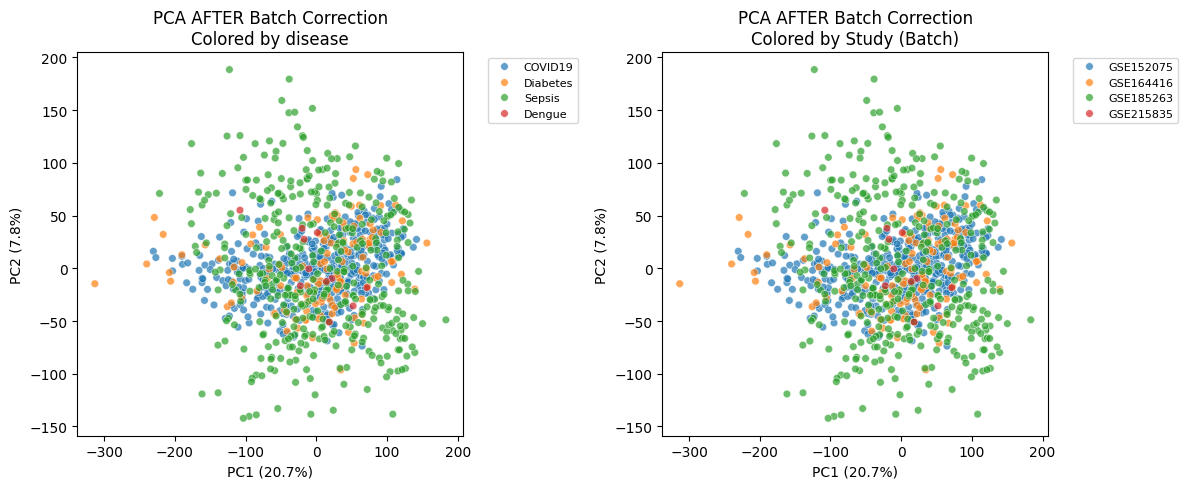

In [9]:
# ============================================================
# CELL 9: PCA visualization AFTER batch correction
# ============================================================
plot_pca(expr_corrected, meta, 'disease', 'PCA AFTER Batch Correction')

In [10]:
# ============================================================
# CELL 10: Prepare ML datasets for each disease
# ============================================================

# Transpose: samples × genes
X_all = expr_corrected.T
X_all.index.name = "sample_id"

# Align metadata
meta_aligned = meta.reindex(X_all.index).copy()

# Remove unknown samples
known_mask = meta_aligned["case_control"] != "Unknown"
X_all = X_all.loc[known_mask]
meta_aligned = meta_aligned.loc[known_mask]

print(f"Total usable samples: {X_all.shape[0]}")
print(f"Total genes: {X_all.shape[1]}")
print(f"\nDisease distribution:")
print(meta_aligned["disease"].value_counts())
print(f"\nCondition distribution:")
print(meta_aligned["condition"].value_counts())


# ============================================================
# Define disease-specific binary tasks
# ============================================================
# For each disease, we compare disease samples vs their controls

DISEASE_TASKS = {}

# Task 1: COVID19 Positive vs Negative
covid_mask = meta_aligned["disease"] == "COVID19"
covid_meta = meta_aligned[covid_mask]
covid_X = X_all.loc[covid_mask]
covid_y = (covid_meta["condition"] == "COVID19_Positive").astype(int)
DISEASE_TASKS["COVID19"] = {
    "X": covid_X, "y": covid_y,
    "groups": covid_meta["gse"],
    "pos_label": "COVID19_Positive",
    "neg_label": "COVID19_Negative"
}

# Task 2: Diabetes (T2D + T3cD) vs No Diabetes Control
diab_mask = meta_aligned["disease"] == "Diabetes"
diab_meta = meta_aligned[diab_mask]
diab_case = diab_meta["condition"].isin(["Diabetes_T2D", "Diabetes_T3cD"])
diab_ctrl = diab_meta["condition"] == "No_Diabetes_Control"
diab_keep = diab_case | diab_ctrl
diab_X = X_all.loc[diab_meta.index[diab_keep]]
diab_y = diab_case[diab_keep].astype(int)
DISEASE_TASKS["Diabetes"] = {
    "X": diab_X, "y": diab_y,
    "groups": diab_meta.loc[diab_keep, "gse"],
    "pos_label": "Diabetes_T2D/T3cD",
    "neg_label": "No_Diabetes_Control"
}

# Task 3: Sepsis vs Healthy
sep_mask = meta_aligned["disease"] == "Sepsis"
sep_meta = meta_aligned[sep_mask]
sep_y = (sep_meta["condition"] == "Sepsis_Case").astype(int)
DISEASE_TASKS["Sepsis"] = {
    "X": X_all.loc[sep_mask], "y": sep_y,
    "groups": sep_meta["gse"],
    "pos_label": "Sepsis_Case",
    "neg_label": "Healthy_Control"
}

# Task 4: Dengue (DF + DHF) — all are cases, no internal controls
# We will compare Dengue vs Sepsis_Healthy as external controls
dengue_mask = meta_aligned["disease"] == "Dengue"
healthy_mask = meta_aligned["condition"] == "Healthy_Control"
deng_combined = dengue_mask | healthy_mask
deng_X = X_all.loc[deng_combined]
deng_y = meta_aligned.loc[deng_combined, "disease"].map(
    lambda x: 1 if x == "Dengue" else 0
)
deng_groups = meta_aligned.loc[deng_combined, "gse"]
DISEASE_TASKS["Dengue"] = {
    "X": deng_X, "y": deng_y,
    "groups": deng_groups,
    "pos_label": "Dengue_DF/DHF",
    "neg_label": "Healthy_Control (from Sepsis study)"
}

# Print summary
print("\n" + "=" * 60)
print("DISEASE TASK SUMMARY")
print("=" * 60)
for name, task in DISEASE_TASKS.items():
    n_pos = task["y"].sum()
    n_neg = len(task["y"]) - n_pos
    print(f"\n  {name}:")
    print(f"    {task['pos_label']}: {n_pos}")
    print(f"    {task['neg_label']}: {n_neg}")
    print(f"    Total: {len(task['y'])}")

Total usable samples: 1020
Total genes: 16523

Disease distribution:
disease
COVID19     484
Sepsis      392
Diabetes    133
Dengue       11
Name: count, dtype: int64

Condition distribution:
condition
COVID19_Positive       430
Sepsis_Case            348
COVID19_Negative        54
Healthy_Control         44
Diabetes_T2D            39
Prediabetes_IGT         38
Diabetes_T3cD           35
No_Diabetes_Control     18
Dengue_DHF               6
Dengue_DF                5
Prediabetes_IFG          3
Name: count, dtype: int64

DISEASE TASK SUMMARY

  COVID19:
    COVID19_Positive: 430
    COVID19_Negative: 54
    Total: 484

  Diabetes:
    Diabetes_T2D/T3cD: 74
    No_Diabetes_Control: 18
    Total: 92

  Sepsis:
    Sepsis_Case: 348
    Healthy_Control: 44
    Total: 392

  Dengue:
    Dengue_DF/DHF: 11
    Healthy_Control (from Sepsis study): 44
    Total: 55


In [11]:
# ============================================================
# CELL 11: Biomarker Discovery (FAST RUN - LR + RF)
# ============================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from collections import defaultdict


def discover_biomarkers(X, y, disease_name, n_splits=3,
                        C_lasso=0.1, top_n=50, max_genes=3000):
    print(f"\n{'='*60}")
    print(f"BIOMARKER DISCOVERY: {disease_name}")
    print(f"{'='*60}")
    print(f"  Samples: {X.shape[0]} (Cases={int(y.sum())}, Ctrl={int(len(y)-y.sum())})")

    # Pre-filter to most variable genes
    if X.shape[1] > max_genes:
        top_var = X.var(axis=0).nlargest(max_genes).index
        X = X[top_var]
    print(f"  Genes: {X.shape[1]}")

    gene_names = X.columns.tolist()
    gene_sel = defaultdict(int)
    gene_coef = defaultdict(float)
    gene_rf_imp = defaultdict(float)
    aucs_lr, aps_lr = [], []
    aucs_rf, aps_rf = [], []

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (tr, te) in enumerate(cv.split(X, y)):
        sc = StandardScaler()
        Xtr = sc.fit_transform(X.iloc[tr])
        Xte = sc.transform(X.iloc[te])
        ytr = y.iloc[tr]
        yte = y.iloc[te]

        # ---- L1 Logistic Regression ----
        lr = LogisticRegression(
            penalty='l1', solver='saga', C=C_lasso,
            max_iter=500, class_weight='balanced',
            random_state=42, tol=1e-3
        )
        lr.fit(Xtr, ytr)

        c = lr.coef_.ravel()
        for i, g in enumerate(gene_names):
            if c[i] != 0:
                gene_sel[g] += 1
            gene_coef[g] += c[i]

        try:
            p = lr.predict_proba(Xte)[:, 1]
            aucs_lr.append(roc_auc_score(yte, p))
            aps_lr.append(average_precision_score(yte, p))
        except:
            pass

        # ---- Random Forest ----
        rf = RandomForestClassifier(
            n_estimators=50,
            max_depth=8,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        rf.fit(Xtr, ytr)

        for i, g in enumerate(gene_names):
            gene_rf_imp[g] += rf.feature_importances_[i]

        try:
            p_rf = rf.predict_proba(Xte)[:, 1]
            aucs_rf.append(roc_auc_score(yte, p_rf))
            aps_rf.append(average_precision_score(yte, p_rf))
        except:
            pass

        print(f"    Fold {fold+1}/{n_splits} done")

    # Build ranking
    rows = []
    for g in gene_names:
        s = gene_sel.get(g, 0)
        mc = gene_coef.get(g, 0) / n_splits
        rf_imp = gene_rf_imp.get(g, 0) / n_splits
        rows.append({
            "gene": g,
            "selection_count": s,
            "stability": s / n_splits,
            "mean_lasso_coef": mc,
            "abs_mean_coef": abs(mc),
            "mean_rf_importance": rf_imp,
            "direction": "UP" if mc > 0 else "DOWN"
        })

    df = pd.DataFrame(rows)
    mx_coef = df["abs_mean_coef"].max() + 1e-9
    mx_rf = df["mean_rf_importance"].max() + 1e-9

    df["combined_score"] = (
        0.4 * df["stability"] +
        0.3 * (df["abs_mean_coef"] / mx_coef) +
        0.3 * (df["mean_rf_importance"] / mx_rf)
    )
    df = df.sort_values("combined_score", ascending=False)

    auc_lr_m = np.mean(aucs_lr) if aucs_lr else 0
    auc_lr_s = np.std(aucs_lr) if aucs_lr else 0
    auc_rf_m = np.mean(aucs_rf) if aucs_rf else 0
    auc_rf_s = np.std(aucs_rf) if aucs_rf else 0
    n_st = int((df["stability"] >= 0.5).sum())

    print(f"\n  L1 LR  AUC: {auc_lr_m:.4f}±{auc_lr_s:.4f}")
    print(f"  RF     AUC: {auc_rf_m:.4f}±{auc_rf_s:.4f}")
    print(f"  Stable genes (≥50%): {n_st}")
    print(f"\n  Top 10 Candidates:")
    print(f"  {'Gene':<15} {'Stab':>5} {'LR_coef':>9} {'RF_imp':>9} {'Dir':>5} {'Score':>7}")
    print(f"  {'-'*55}")
    for _, r in df.head(10).iterrows():
        print(f"  {r['gene']:<15} {r['stability']:>5.2f} "
              f"{r['mean_lasso_coef']:>9.4f} {r['mean_rf_importance']:>9.6f} "
              f"{r['direction']:>5} {r['combined_score']:>7.4f}")

    return {
        "disease": disease_name,
        "ranking": df,
        "mean_auc": auc_lr_m,
        "std_auc": auc_lr_s,
        "mean_auc_rf": auc_rf_m,
        "std_auc_rf": auc_rf_s,
        "mean_ap": np.mean(aps_lr) if aps_lr else 0,
        "n_samples": X.shape[0],
        "n_genes": X.shape[1],
        "n_stable_50": n_st,
        "top_biomarkers": df.head(top_n)
    }

print("Ready ✅ (LR + RF)")

Ready ✅ (LR + RF)


In [12]:
# ============================================================
# CELL 12: Run biomarker discovery (FAST - LR + RF)
# ============================================================

all_results = {}

for disease_name, task in DISEASE_TASKS.items():
    X = task["X"]
    y = task["y"]
    n_pos = int(y.sum())
    n_neg = int(len(y) - n_pos)

    if n_pos < 3 or n_neg < 3:
        print(f"\n⚠️ Skipping {disease_name}: pos={n_pos}, neg={n_neg}")
        continue

    results = discover_biomarkers(
        X=X, y=y,
        disease_name=disease_name,
        n_splits=3,
        C_lasso=0.1,
        top_n=50,
        max_genes=3000
    )
    all_results[disease_name] = results

print("\n" + "=" * 60)
print("ALL DONE ✅")
print("=" * 60)


BIOMARKER DISCOVERY: COVID19
  Samples: 484 (Cases=430, Ctrl=54)
  Genes: 3000
    Fold 1/3 done
    Fold 2/3 done
    Fold 3/3 done

  L1 LR  AUC: 0.9894±0.0081
  RF     AUC: 0.9757±0.0248
  Stable genes (≥50%): 36

  Top 10 Candidates:
  Gene             Stab   LR_coef    RF_imp   Dir   Score
  -------------------------------------------------------
  IFI44L           1.00    0.2144  0.020658    UP  0.8846
  IFIT1            1.00    0.0816  0.033564    UP  0.8141
  IGFBP2           1.00   -0.1981  0.010005  DOWN  0.7666
  XAF1             1.00    0.2021  0.008472    UP  0.7585
  OAS2             0.67    0.1165  0.028712    UP  0.6863
  PCSK5            1.00    0.1034  0.014093    UP  0.6706
  SBK1             1.00    0.1592  0.004600    UP  0.6638
  H2AJ             1.00   -0.0793  0.010989  DOWN  0.6092
  CD163            1.00    0.1296  0.002401    UP  0.6028
  CXCL9            1.00    0.1316  0.000447    UP  0.5881

BIOMARKER DISCOVERY: Diabetes
  Samples: 92 (Cases=74, Ctrl=18)


In [13]:
# ============================================================
# CELL 13: Differential expression analysis
# ============================================================
from scipy import stats
from statsmodels.stats.multitest import multipletests


def run_de_analysis(X, y):
    """
    Simple DE analysis: t-test + log2 fold change.
    X is already log2(CPM+1), so difference = log2FC.
    """
    case_idx = y == 1
    ctrl_idx = y == 0

    X_case = X.loc[case_idx]
    X_ctrl = X.loc[ctrl_idx]

    results = []
    for gene in X.columns:
        case_vals = X_case[gene].values
        ctrl_vals = X_ctrl[gene].values

        # log2FC (already log-transformed so difference = fold change)
        log2fc = case_vals.mean() - ctrl_vals.mean()

        # Welch's t-test
        try:
            t_stat, p_val = stats.ttest_ind(case_vals, ctrl_vals, equal_var=False)
        except:
            t_stat, p_val = 0, 1.0

        results.append({
            "gene": gene,
            "log2FC": log2fc,
            "mean_case": case_vals.mean(),
            "mean_control": ctrl_vals.mean(),
            "t_statistic": t_stat,
            "p_value": p_val if not np.isnan(p_val) else 1.0
        })

    de_df = pd.DataFrame(results)

    # FDR correction (Benjamini-Hochberg)
    _, de_df["adj_p_value"], _, _ = multipletests(
        de_df["p_value"].fillna(1), method="fdr_bh"
    )

    de_df["abs_log2FC"] = de_df["log2FC"].abs()
    de_df["significant"] = (de_df["adj_p_value"] < 0.05) & (de_df["abs_log2FC"] > 0.5)
    de_df = de_df.sort_values("p_value")

    return de_df


# Run DE for each disease
de_results = {}

for disease_name, task in DISEASE_TASKS.items():
    if disease_name not in all_results:
        continue

    print(f"\n--- DE Analysis: {disease_name} ---")
    de_df = run_de_analysis(task["X"], task["y"])

    n_sig = de_df["significant"].sum()
    n_up = ((de_df["significant"]) & (de_df["log2FC"] > 0)).sum()
    n_down = ((de_df["significant"]) & (de_df["log2FC"] < 0)).sum()

    print(f"  Significant DEGs (|log2FC|>0.5, adjP<0.05): {n_sig}")
    print(f"    Upregulated:   {n_up}")
    print(f"    Downregulated: {n_down}")

    de_results[disease_name] = de_df

print("\n✅ DE analysis complete")


--- DE Analysis: COVID19 ---
  Significant DEGs (|log2FC|>0.5, adjP<0.05): 5066
    Upregulated:   1078
    Downregulated: 3988

--- DE Analysis: Diabetes ---
  Significant DEGs (|log2FC|>0.5, adjP<0.05): 1275
    Upregulated:   1140
    Downregulated: 135

--- DE Analysis: Sepsis ---
  Significant DEGs (|log2FC|>0.5, adjP<0.05): 10076
    Upregulated:   1764
    Downregulated: 8312

--- DE Analysis: Dengue ---
  Significant DEGs (|log2FC|>0.5, adjP<0.05): 5042
    Upregulated:   413
    Downregulated: 4629

✅ DE analysis complete


In [14]:
# ============================================================
# CELL 14: Combine ML selection + DE significance
# ============================================================
# A gene is a STRONG biomarker if:
#   1. ML selected it consistently (stability ≥ 50%)
#   2. It is statistically significant (adjP < 0.05)
#   3. It has meaningful fold change (|log2FC| > 0.5)

final_biomarkers = {}

for disease_name in all_results:
    if disease_name not in de_results:
        continue

    ml_ranking = all_results[disease_name]["ranking"].copy()
    de_df = de_results[disease_name].copy()

    # Merge ML and DE results on gene name
    merged = ml_ranking.merge(de_df, on="gene", how="left")

    # Define strong biomarker criteria
    merged["ml_stable"] = merged["stability"] >= 0.5
    merged["de_significant"] = merged["significant"].fillna(False)
    merged["is_strong_biomarker"] = merged["ml_stable"] & merged["de_significant"]

    # Final score combining all evidence
    max_coef = merged["abs_mean_coef"].max() + 1e-9
    max_rf = merged["mean_rf_importance"].max() + 1e-9
    max_fc = merged["abs_log2FC"].max() + 1e-9

    merged["final_score"] = (
        0.30 * merged["stability"] +
        0.20 * (merged["abs_mean_coef"] / max_coef).fillna(0) +
        0.20 * (merged["mean_rf_importance"] / max_rf).fillna(0) +
        0.30 * (merged["abs_log2FC"] / max_fc).fillna(0)
    )

    merged = merged.sort_values("final_score", ascending=False)

    n_strong = merged["is_strong_biomarker"].sum()

    print(f"\n{'='*60}")
    print(f"{disease_name} BIOMARKER SUMMARY")
    print(f"{'='*60}")
    print(f"  ML-stable genes (≥50% folds):  {merged['ml_stable'].sum()}")
    print(f"  DE-significant genes:          {merged['de_significant'].sum()}")
    print(f"  STRONG biomarkers (ML+DE):     {n_strong}")

    # Show top genes
    if n_strong > 0:
        top = merged[merged["is_strong_biomarker"]].head(20)
    else:
        print("  No strong biomarkers. Showing top ML genes instead:")
        top = merged.head(20)

    print(f"\n  {'Gene':<15} {'Stab':>5} {'log2FC':>8} {'adjP':>10} {'Dir':>5} {'Score':>7}")
    print(f"  {'-'*55}")
    for _, row in top.iterrows():
        print(f"  {row['gene']:<15} {row['stability']:>5.2f} "
              f"{row.get('log2FC',0):>8.3f} {row.get('adj_p_value',1):>10.2e} "
              f"{row['direction']:>5} {row['final_score']:>7.4f}")

    final_biomarkers[disease_name] = merged

print("\n✅ ML + DE integration complete")


COVID19 BIOMARKER SUMMARY
  ML-stable genes (≥50% folds):  36
  DE-significant genes:          1635
  STRONG biomarkers (ML+DE):     35

  Gene             Stab   log2FC       adjP   Dir   Score
  -------------------------------------------------------
  IFI44L           1.00    4.352   1.02e-16    UP  0.9231
  IFIT1            1.00    4.004   1.18e-19    UP  0.8521
  XAF1             1.00    3.067   1.04e-14    UP  0.7505
  IGFBP2           1.00   -2.948   8.97e-14  DOWN  0.7476
  OAS2             0.67    3.105   2.08e-14    UP  0.6938
  OAS3             0.67    3.400   2.43e-16    UP  0.6391
  PCSK5            1.00    2.267   8.59e-16    UP  0.6367
  SBK1             1.00    2.210   2.96e-14    UP  0.6282
  CXCL10           1.00    3.708   2.86e-32    UP  0.6192
  CXCL9            1.00    2.721   1.14e-18    UP  0.6129
  CD163            1.00    2.567   1.56e-13    UP  0.6122
  PLA2G7           1.00    3.028   4.35e-24    UP  0.6100
  RRAD             1.00   -2.391   1.24e-10  DOWN 

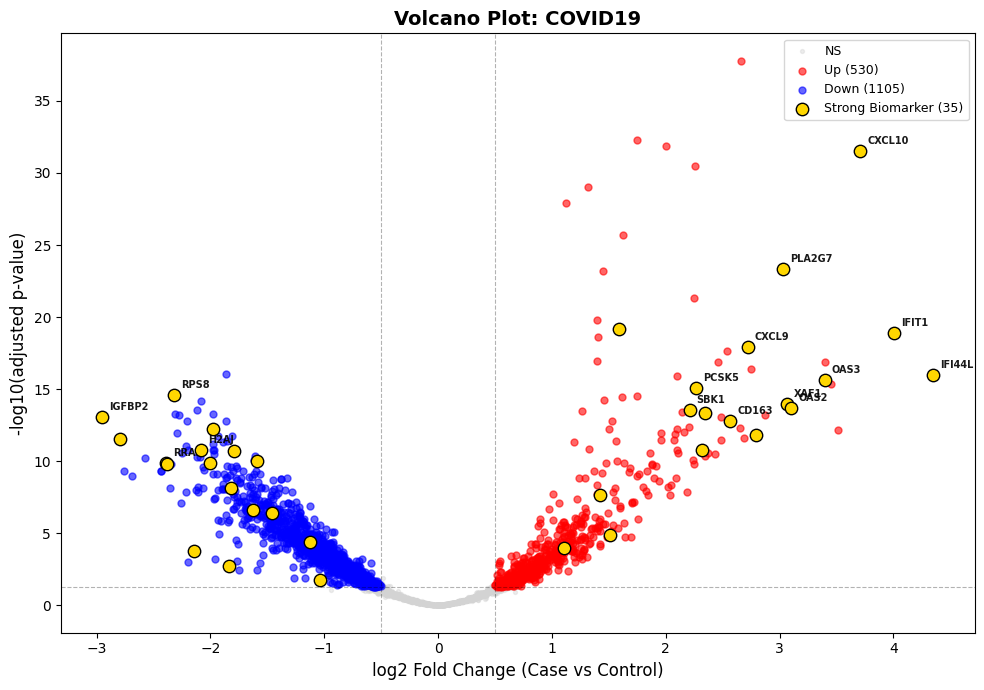

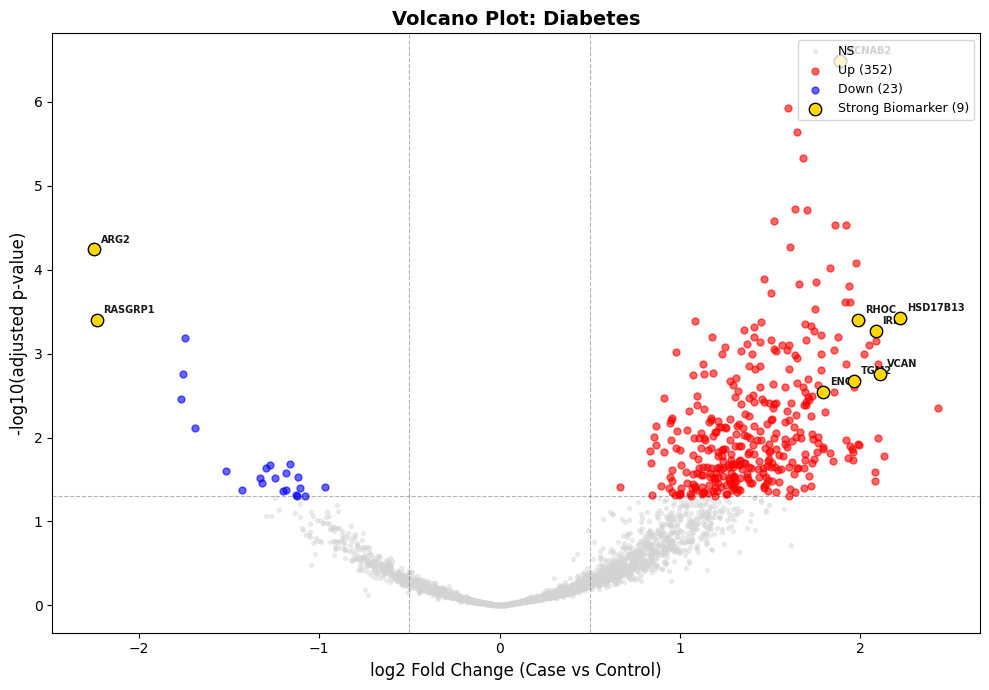

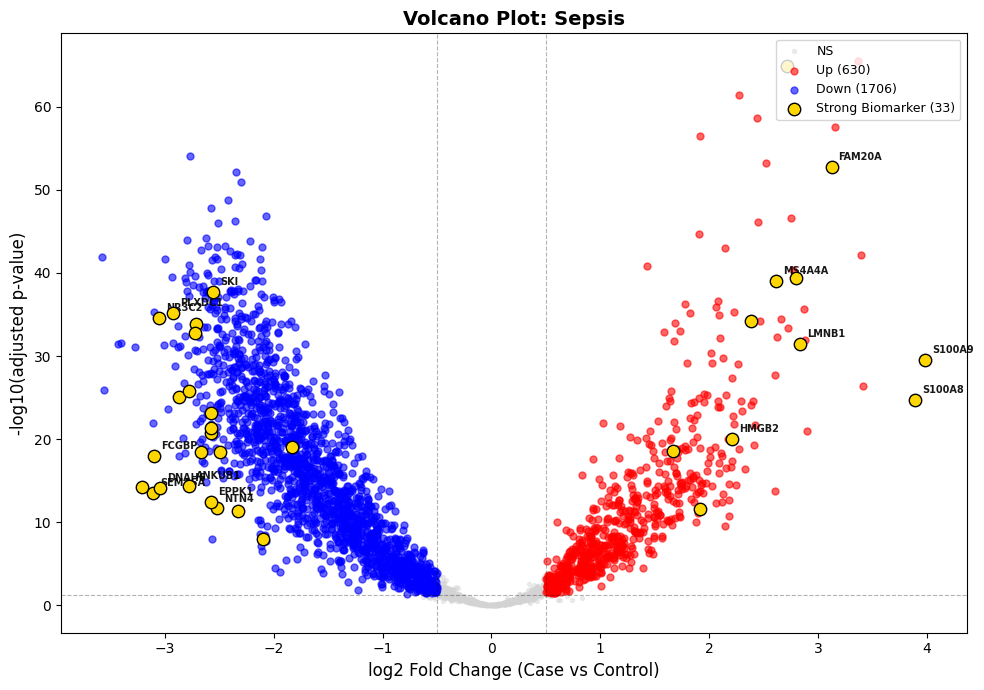

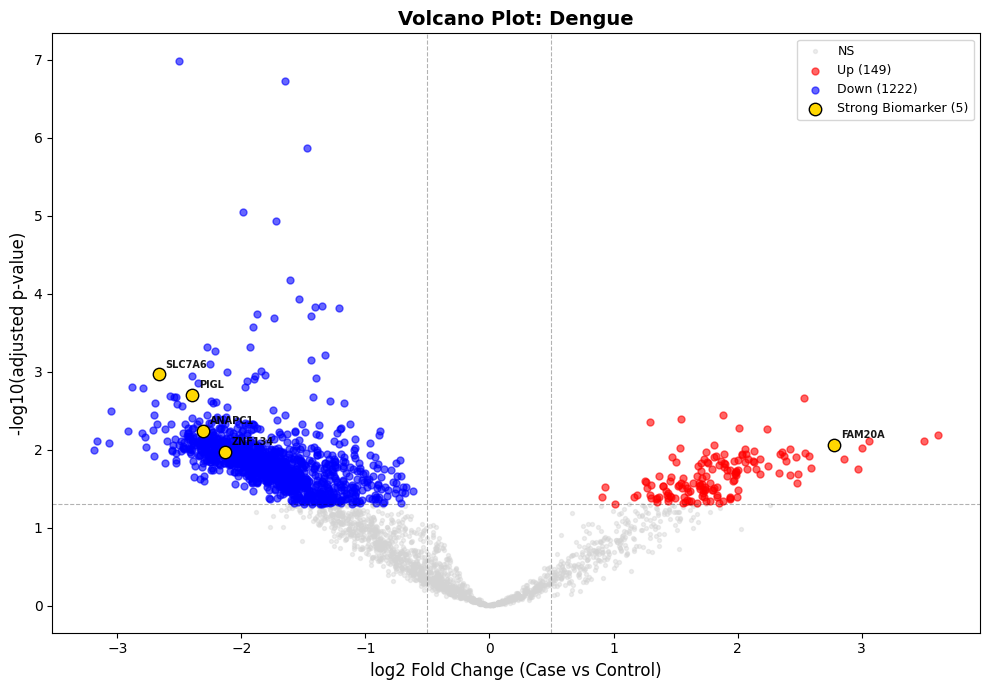

✅ Volcano plots complete


In [15]:
# ============================================================
# CELL 15: Volcano plots for each disease
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns


def plot_volcano(merged_df, disease_name, top_n=15, figsize=(10, 7)):
    """
    Volcano plot showing:
      - x-axis: log2 Fold Change (case vs control)
      - y-axis: -log10(adjusted p-value)
      - Red dots: upregulated significant genes
      - Blue dots: downregulated significant genes
      - Labels: top strong biomarkers
    """
    df = merged_df.copy()
    df["-log10p"] = -np.log10(df["adj_p_value"].clip(lower=1e-300))

    fig, ax = plt.subplots(figsize=figsize)

    # Non-significant (grey)
    ns = df[~df["significant"].fillna(False)]
    ax.scatter(ns["log2FC"], ns["-log10p"], c="lightgrey", alpha=0.4, s=8, label="NS")

    # Significant UP (red)
    sig = df[df["significant"].fillna(False)]
    up = sig[sig["log2FC"] > 0]
    down = sig[sig["log2FC"] < 0]

    ax.scatter(up["log2FC"], up["-log10p"],
               c="red", alpha=0.6, s=25, label=f"Up ({len(up)})")
    ax.scatter(down["log2FC"], down["-log10p"],
               c="blue", alpha=0.6, s=25, label=f"Down ({len(down)})")

    # Highlight strong biomarkers with bigger markers
    if "is_strong_biomarker" in df.columns:
        strong = df[df["is_strong_biomarker"]]
        ax.scatter(strong["log2FC"], strong["-log10p"],
                   c="gold", edgecolors="black", s=80, zorder=5,
                   label=f"Strong Biomarker ({len(strong)})")

    # Label top genes
    if "is_strong_biomarker" in df.columns and df["is_strong_biomarker"].any():
        label_df = df[df["is_strong_biomarker"]].head(top_n)
    else:
        label_df = df[df["significant"].fillna(False)].head(top_n)

    for _, row in label_df.iterrows():
        ax.annotate(
            row["gene"],
            (row["log2FC"], row["-log10p"]),
            fontsize=7, alpha=0.9, fontweight="bold",
            xytext=(5, 5), textcoords="offset points",
            arrowprops=dict(arrowstyle="-", alpha=0.3, lw=0.5)
        )

    # Threshold lines
    ax.axhline(-np.log10(0.05), ls="--", c="black", alpha=0.3, lw=0.8)
    ax.axvline(-0.5, ls="--", c="black", alpha=0.3, lw=0.8)
    ax.axvline(0.5, ls="--", c="black", alpha=0.3, lw=0.8)

    ax.set_xlabel("log2 Fold Change (Case vs Control)", fontsize=12)
    ax.set_ylabel("-log10(adjusted p-value)", fontsize=12)
    ax.set_title(f"Volcano Plot: {disease_name}", fontsize=14, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()


# Plot for each disease
for disease_name, merged_df in final_biomarkers.items():
    if "log2FC" in merged_df.columns and "adj_p_value" in merged_df.columns:
        plot_volcano(merged_df, disease_name)
    else:
        print(f"Skipping volcano for {disease_name}: missing DE columns")

print("✅ Volcano plots complete")

Plotting heatmap with 33 genes from 4 diseases


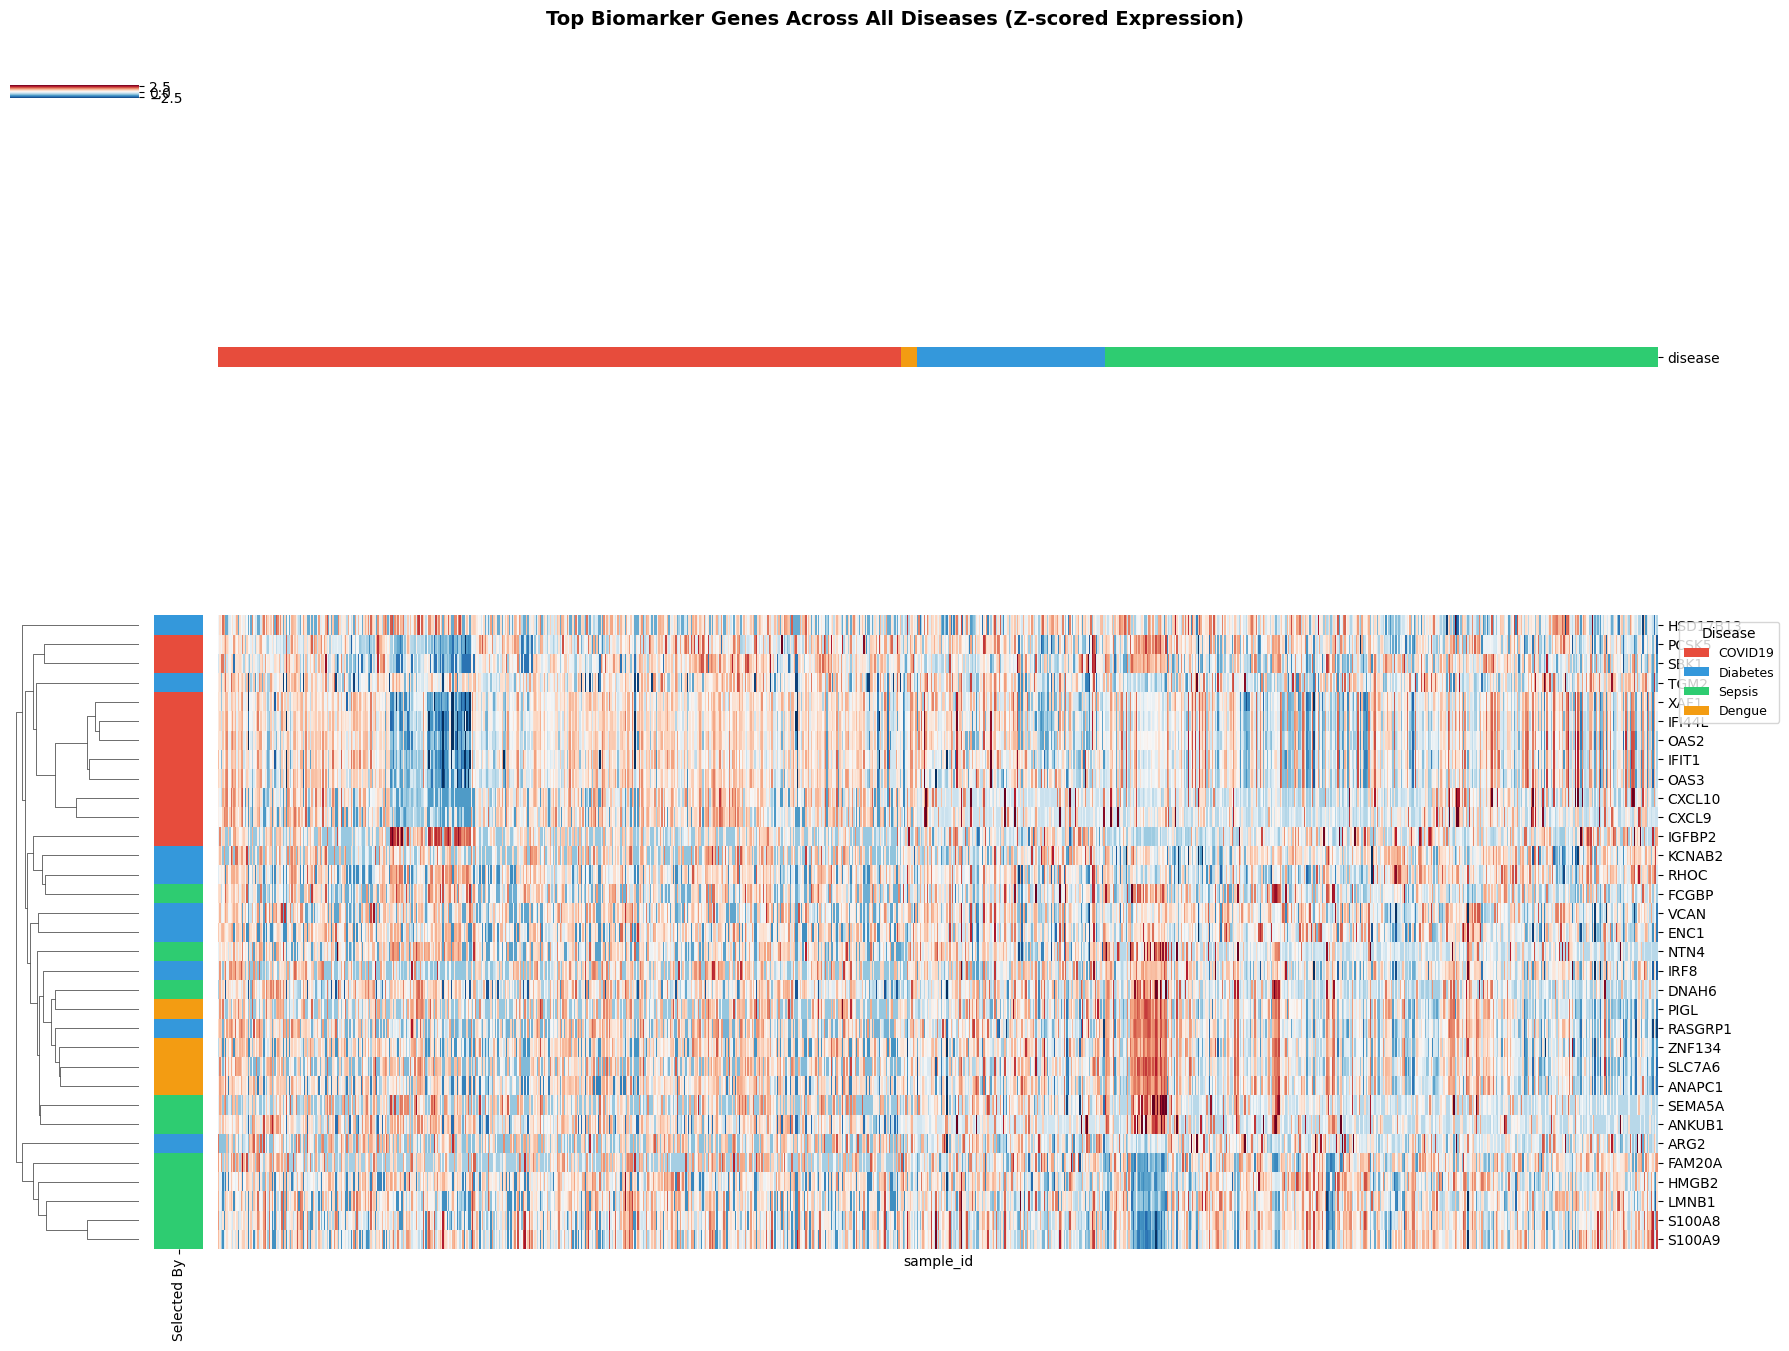


Genes in heatmap (33):
  IFI44L          selected by: COVID19
  IFIT1           selected by: COVID19
  XAF1            selected by: COVID19
  IGFBP2          selected by: COVID19
  OAS2            selected by: COVID19
  OAS3            selected by: COVID19
  PCSK5           selected by: COVID19
  SBK1            selected by: COVID19
  CXCL10          selected by: COVID19
  CXCL9           selected by: COVID19
  ARG2            selected by: Diabetes
  RASGRP1         selected by: Diabetes
  HSD17B13        selected by: Diabetes
  KCNAB2          selected by: Diabetes
  VCAN            selected by: Diabetes
  IRF8            selected by: Diabetes
  RHOC            selected by: Diabetes
  TGM2            selected by: Diabetes
  ENC1            selected by: Diabetes
  FAM20A          selected by: Sepsis
  SEMA5A          selected by: Sepsis
  S100A8          selected by: Sepsis
  ANKUB1          selected by: Sepsis
  LMNB1           selected by: Sepsis
  S100A9          selected by: Sepsi

In [16]:
# ============================================================
# CELL 16: Heatmap of top biomarkers across ALL diseases
# ============================================================
# WHAT THIS HEATMAP SHOWS:
# ─────────────────────────
# Rows    = Top biomarker genes (selected by ML+DE from each disease)
# Columns = All 1,020 samples (grouped by disease)
# Colors  = Z-scored expression:
#             RED  = higher expression than average
#             BLUE = lower expression than average
#             WHITE = average expression
# Top color bar = Disease label (which disease each sample belongs to)
#
# PURPOSE:
# You can visually see:
#   1. Which genes are UP in which disease
#   2. Which genes are DOWN in which disease
#   3. Disease-SPECIFIC patterns (gene UP only in Dengue but not others)
#   4. Shared patterns (gene UP in both Sepsis and COVID)

def plot_biomarker_heatmap(final_biomarkers, expr_data, meta_df,
                           top_n=10, figsize=(18, 10)):
    """
    Heatmap of top biomarker genes across all samples.
    """
    # Collect top genes from each disease
    all_top_genes = []
    gene_source = {}  # which disease selected this gene

    for disease, merged in final_biomarkers.items():
        if "is_strong_biomarker" in merged.columns and merged["is_strong_biomarker"].any():
            top = merged[merged["is_strong_biomarker"]].head(top_n)
        else:
            top = merged.head(top_n)

        for gene in top["gene"].values:
            if gene not in gene_source and gene in expr_data.index:
                gene_source[gene] = disease
                all_top_genes.append(gene)

    if len(all_top_genes) == 0:
        print("No valid biomarker genes found for heatmap.")
        return

    print(f"Plotting heatmap with {len(all_top_genes)} genes from {len(final_biomarkers)} diseases")

    # Subset expression matrix
    hm_data = expr_data.loc[all_top_genes]

    # Sort samples by disease
    aligned_meta = meta_df.reindex(hm_data.columns)
    sort_order = aligned_meta.sort_values("disease").index
    hm_data = hm_data[sort_order]
    aligned_meta = aligned_meta.loc[sort_order]

    # Z-score per gene (row-wise normalization)
    # This makes each gene comparable regardless of absolute expression level
    row_means = hm_data.mean(axis=1)
    row_stds = hm_data.std(axis=1).replace(0, 1)  # avoid division by zero
    hm_z = hm_data.sub(row_means, axis=0).div(row_stds, axis=0)

    # Clip extreme values for better visualization
    hm_z = hm_z.clip(-3, 3)

    # Disease color mapping for the column color bar
    disease_colors = {
        "COVID19": "#e74c3c",     # red
        "Diabetes": "#3498db",    # blue
        "Sepsis": "#2ecc71",      # green
        "Dengue": "#f39c12"       # orange
    }
    col_colors = aligned_meta["disease"].map(disease_colors).fillna("grey")

    # Gene source color mapping for row color bar
    row_colors = pd.Series(
        [disease_colors.get(gene_source.get(g, ""), "grey") for g in all_top_genes],
        index=all_top_genes,
        name="Selected By"
    )

    # Plot
    fig_height = max(6, len(all_top_genes) * 0.4)

    g = sns.clustermap(
        hm_z,
        cmap="RdBu_r",          # Red=high, Blue=low
        vmin=-3, vmax=3,
        col_cluster=False,       # Don't rearrange samples (keep disease order)
        row_cluster=True,        # Cluster genes by similarity
        col_colors=col_colors,   # Disease label on top
        row_colors=row_colors,   # Which disease selected this gene (left side)
        figsize=(figsize[0], fig_height),
        xticklabels=False,       # Too many samples to show names
        yticklabels=True,        # Show gene names
        dendrogram_ratio=(0.08, 0.02),
        cbar_pos=(0.02, 0.8, 0.03, 0.15),
        linewidths=0
    )

    g.fig.suptitle(
        "Top Biomarker Genes Across All Diseases (Z-scored Expression)",
        y=1.02, fontsize=14, fontweight="bold"
    )

    # Add disease legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=c, label=d) for d, c in disease_colors.items()
    ]
    g.ax_heatmap.legend(
        handles=legend_elements,
        loc='upper left',
        bbox_to_anchor=(1.01, 1),
        fontsize=9,
        title="Disease",
        title_fontsize=10
    )

    plt.tight_layout()
    plt.show()

    # Print gene list
    print(f"\nGenes in heatmap ({len(all_top_genes)}):")
    for gene in all_top_genes:
        print(f"  {gene:<15} selected by: {gene_source[gene]}")


# Run heatmap
plot_biomarker_heatmap(
    final_biomarkers,
    expr_corrected,
    meta,
    top_n=10    # top 10 genes per disease
)

In [17]:
# ============================================================
# CELL 17: Compare biomarkers across diseases
# ============================================================

def compare_biomarkers(final_biomarkers, stability_threshold=0.5):
    """Find disease-specific and shared biomarker genes."""

    disease_genes = {}
    for disease, merged in final_biomarkers.items():
        stable = merged[merged["stability"] >= stability_threshold]
        disease_genes[disease] = set(stable["gene"].tolist())

    diseases = list(disease_genes.keys())

    print("=" * 60)
    print("BIOMARKER COMPARISON ACROSS DISEASES")
    print("=" * 60)

    # Per disease count
    for d in diseases:
        print(f"\n  {d}: {len(disease_genes[d])} stable genes")

    # Pairwise overlap
    print(f"\n  Pairwise overlaps:")
    for i in range(len(diseases)):
        for j in range(i+1, len(diseases)):
            d1, d2 = diseases[i], diseases[j]
            overlap = disease_genes[d1] & disease_genes[d2]
            print(f"    {d1} ∩ {d2}: {len(overlap)} genes")
            if 0 < len(overlap) <= 20:
                print(f"      → {sorted(overlap)}")

    # Disease-SPECIFIC genes (only in one disease)
    print(f"\n  Disease-SPECIFIC biomarkers:")
    specific_genes = {}
    for d in diseases:
        other = set()
        for d2 in diseases:
            if d2 != d:
                other |= disease_genes[d2]
        specific = disease_genes[d] - other
        specific_genes[d] = specific
        print(f"\n    {d}-specific ({len(specific)} genes):")
        if len(specific) > 0:
            print(f"      {sorted(specific)[:25]}")

    # Pan-disease genes (in ALL diseases)
    if len(diseases) > 1:
        pan = set.intersection(*disease_genes.values())
        print(f"\n  Pan-disease biomarkers (in ALL diseases): {len(pan)}")
        if 0 < len(pan) <= 30:
            print(f"    {sorted(pan)}")

    return disease_genes, specific_genes

disease_gene_sets, specific_gene_sets = compare_biomarkers(
    final_biomarkers, stability_threshold=0.5
)

BIOMARKER COMPARISON ACROSS DISEASES

  COVID19: 36 stable genes

  Diabetes: 9 stable genes

  Sepsis: 33 stable genes

  Dengue: 5 stable genes

  Pairwise overlaps:
    COVID19 ∩ Diabetes: 0 genes
    COVID19 ∩ Sepsis: 1 genes
      → ['C1QB']
    COVID19 ∩ Dengue: 0 genes
    Diabetes ∩ Sepsis: 0 genes
    Diabetes ∩ Dengue: 0 genes
    Sepsis ∩ Dengue: 1 genes
      → ['FAM20A']

  Disease-SPECIFIC biomarkers:

    COVID19-specific (35 genes):
      ['CD163', 'CD82', 'CES1', 'CLSTN1', 'CRIP1', 'CXCL10', 'CXCL9', 'DDX60', 'EPB41L2', 'EPSTI1', 'H2AJ', 'HERC6', 'IFI44L', 'IFIT1', 'IGFBP2', 'IGFBP5', 'IGHG3', 'IGKC', 'IGKV4-1', 'LILRB4', 'NDUFV1', 'OAS2', 'OAS3', 'PCSK5', 'PLA2G7']

    Diabetes-specific (9 genes):
      ['ARG2', 'ENC1', 'HSD17B13', 'IRF8', 'KCNAB2', 'RASGRP1', 'RHOC', 'TGM2', 'VCAN']

    Sepsis-specific (31 genes):
      ['AFAP1', 'AIM2', 'ALS2CL', 'ANKUB1', 'ATP5F1E', 'C1QC', 'CACHD1', 'CACNB4', 'CEP68', 'DNAH6', 'EPHX2', 'EPPK1', 'FCGBP', 'GNRHR2', 'H4C8', 'HMGB2'

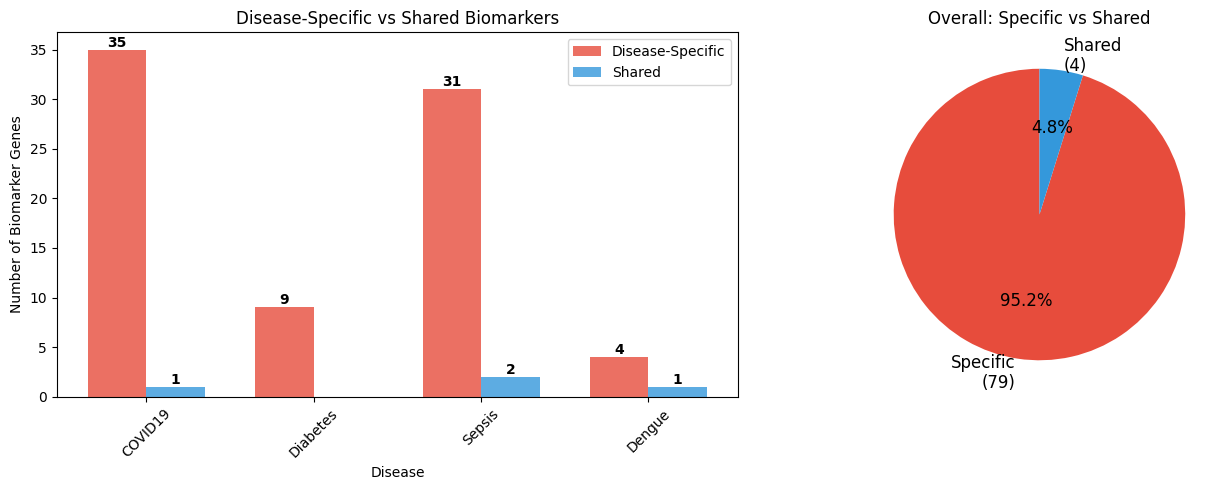

In [18]:
# ============================================================
# CELL 18: Bar chart - disease-specific vs shared biomarkers
# ============================================================

def plot_biomarker_comparison(disease_gene_sets):
    diseases = list(disease_gene_sets.keys())

    if len(diseases) < 2:
        print("Need at least 2 diseases.")
        return

    specific = {}
    shared = {}

    for d in diseases:
        others = set()
        for d2 in diseases:
            if d2 != d:
                others |= disease_gene_sets[d2]
        specific[d] = len(disease_gene_sets[d] - others)
        shared[d] = len(disease_gene_sets[d] & others)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart
    x = np.arange(len(diseases))
    w = 0.35

    bars1 = axes[0].bar(x - w/2, [specific[d] for d in diseases],
                        w, label='Disease-Specific', color='#e74c3c', alpha=0.8)
    bars2 = axes[0].bar(x + w/2, [shared[d] for d in diseases],
                        w, label='Shared', color='#3498db', alpha=0.8)

    axes[0].set_xlabel('Disease')
    axes[0].set_ylabel('Number of Biomarker Genes')
    axes[0].set_title('Disease-Specific vs Shared Biomarkers')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(diseases, rotation=45)
    axes[0].legend()

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            axes[0].annotate(f'{int(h)}', xy=(bar.get_x() + bar.get_width()/2, h),
                           ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Pie chart: total specific vs shared
    total_specific = sum(specific.values())
    total_shared = sum(shared.values())

    if total_specific + total_shared > 0:
        axes[1].pie(
            [total_specific, total_shared],
            labels=[f'Specific\n({total_specific})', f'Shared\n({total_shared})'],
            colors=['#e74c3c', '#3498db'],
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 12}
        )
        axes[1].set_title('Overall: Specific vs Shared')

    plt.tight_layout()
    plt.show()

plot_biomarker_comparison(disease_gene_sets)

In [19]:
# ============================================================
# CELL 19: Save all results
# ============================================================
import os

RESULTS_DIR = os.path.join(BASE_PATH, "biomarker_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# 1. Biomarker rankings per disease
for disease, merged in final_biomarkers.items():
    safe = disease.replace("/", "_").replace(" ", "_")

    # Full ranking
    merged.to_csv(os.path.join(RESULTS_DIR, f"{safe}_full_ranking.csv"), index=False)

    # Strong biomarkers only
    if "is_strong_biomarker" in merged.columns:
        strong = merged[merged["is_strong_biomarker"]]
        strong.to_csv(os.path.join(RESULTS_DIR, f"{safe}_strong_biomarkers.csv"), index=False)

    # Top 50
    merged.head(50).to_csv(os.path.join(RESULTS_DIR, f"{safe}_top50.csv"), index=False)

# 2. DE results
for disease, de_df in de_results.items():
    safe = disease.replace("/", "_").replace(" ", "_")
    de_df.to_csv(os.path.join(RESULTS_DIR, f"{safe}_DE_results.csv"), index=False)

# 3. Performance summary
perf = []
for disease, res in all_results.items():
    perf.append({
        "Disease": disease,
        "Samples": res["n_samples"],
        "Genes": res["n_genes"],
        "AUC_ROC": f"{res['mean_auc']:.4f}±{res['std_auc']:.4f}",
        "Avg_Precision": f"{res.get('mean_ap', 0):.4f}",
        "Stable_Genes": res.get("n_stable_50", 0)
    })
pd.DataFrame(perf).to_csv(os.path.join(RESULTS_DIR, "performance_summary.csv"), index=False)

# 4. Disease-specific gene lists
for disease, genes in specific_gene_sets.items():
    safe = disease.replace("/", "_").replace(" ", "_")
    pd.DataFrame({"gene": sorted(genes)}).to_csv(
        os.path.join(RESULTS_DIR, f"{safe}_specific_genes.csv"), index=False
    )

# 5. Batch-corrected expression
expr_corrected.to_csv(os.path.join(RESULTS_DIR, "expression_batch_corrected.csv"))

# 6. Clean metadata
meta.to_csv(os.path.join(RESULTS_DIR, "metadata_clean.csv"))

print("All results saved to:")
print(f"  {RESULTS_DIR}\n")
for f in sorted(os.listdir(RESULTS_DIR)):
    sz = os.path.getsize(os.path.join(RESULTS_DIR, f))
    print(f"  📄 {f} ({sz/1024:.1f} KB)")

All results saved to:
  /content/drive/MyDrive/compendium_output/biomarker_results

  📄 COVID19_DE_results.csv (2396.8 KB)
  📄 COVID19_full_ranking.csv (665.7 KB)
  📄 COVID19_specific_genes.csv (0.2 KB)
  📄 COVID19_strong_biomarkers.csv (9.8 KB)
  📄 COVID19_top50.csv (14.1 KB)
  📄 Dengue_DE_results.csv (2377.9 KB)
  📄 Dengue_full_ranking.csv (631.3 KB)
  📄 Dengue_specific_genes.csv (0.0 KB)
  📄 Dengue_strong_biomarkers.csv (1.6 KB)
  📄 Dengue_top50.csv (13.5 KB)
  📄 Diabetes_DE_results.csv (2371.7 KB)
  📄 Diabetes_full_ranking.csv (639.7 KB)
  📄 Diabetes_specific_genes.csv (0.1 KB)
  📄 Diabetes_strong_biomarkers.csv (2.7 KB)
  📄 Diabetes_top50.csv (13.3 KB)
  📄 Sepsis_DE_results.csv (2416.6 KB)
  📄 Sepsis_full_ranking.csv (646.1 KB)
  📄 Sepsis_specific_genes.csv (0.2 KB)
  📄 Sepsis_strong_biomarkers.csv (9.1 KB)
  📄 Sepsis_top50.csv (13.8 KB)
  📄 expression_batch_corrected.csv (307102.5 KB)
  📄 metadata_clean.csv (1709.0 KB)
  📄 performance_summary.csv (0.2 KB)


In [20]:
# ============================================================
# CELL 21: Setup ALL condition-level tasks
# ============================================================
# Instead of just Disease-level (COVID vs Diabetes vs Sepsis vs Dengue),
# now we go INSIDE each disease to find condition-specific biomarkers

print("=" * 70)
print("CONDITION-SPECIFIC BIOMARKER SETUP")
print("=" * 70)

# Transpose expression: samples × genes
X_all = expr_corrected.T
meta_aligned = meta.reindex(X_all.index).copy()

# Show all available conditions
print("\nAll conditions in the dataset:")
print(meta_aligned["condition"].value_counts())

# ============================================================
# Define CONDITION-LEVEL tasks
# ============================================================
CONDITION_TASKS = {}

# --- COVID19: Positive vs Negative ---
covid_mask = meta_aligned["disease"] == "COVID19"
covid_meta = meta_aligned[covid_mask]
pos_mask = covid_meta["condition"] == "COVID19_Positive"
neg_mask = covid_meta["condition"] == "COVID19_Negative"
if pos_mask.sum() >= 3 and neg_mask.sum() >= 3:
    keep = pos_mask | neg_mask
    CONDITION_TASKS["COVID19_Pos_vs_Neg"] = {
        "X": X_all.loc[covid_meta.index[keep]],
        "y": pos_mask[keep].astype(int),
        "pos_label": "COVID19_Positive",
        "neg_label": "COVID19_Negative"
    }

# --- Diabetes: T2D vs ND (Control) ---
diab_mask = meta_aligned["disease"] == "Diabetes"
diab_meta = meta_aligned[diab_mask]
for diab_type in ["Diabetes_T2D", "Diabetes_T3cD", "Prediabetes_IGT"]:
    case_mask = diab_meta["condition"] == diab_type
    ctrl_mask = diab_meta["condition"] == "No_Diabetes_Control"
    if case_mask.sum() >= 3 and ctrl_mask.sum() >= 3:
        keep = case_mask | ctrl_mask
        safe_name = f"{diab_type}_vs_Control"
        CONDITION_TASKS[safe_name] = {
            "X": X_all.loc[diab_meta.index[keep]],
            "y": case_mask[keep].astype(int),
            "pos_label": diab_type,
            "neg_label": "No_Diabetes_Control"
        }

# --- Diabetes: T2D vs T3cD (head-to-head) ---
t2d_mask = diab_meta["condition"] == "Diabetes_T2D"
t3cd_mask = diab_meta["condition"] == "Diabetes_T3cD"
if t2d_mask.sum() >= 3 and t3cd_mask.sum() >= 3:
    keep = t2d_mask | t3cd_mask
    CONDITION_TASKS["T2D_vs_T3cD"] = {
        "X": X_all.loc[diab_meta.index[keep]],
        "y": t2d_mask[keep].astype(int),
        "pos_label": "T2D",
        "neg_label": "T3cD"
    }

# --- Sepsis: Sepsis vs Healthy ---
sep_mask = meta_aligned["disease"] == "Sepsis"
sep_meta = meta_aligned[sep_mask]
case_mask = sep_meta["condition"] == "Sepsis_Case"
ctrl_mask = sep_meta["condition"] == "Healthy_Control"
if case_mask.sum() >= 3 and ctrl_mask.sum() >= 3:
    keep = case_mask | ctrl_mask
    CONDITION_TASKS["Sepsis_vs_Healthy"] = {
        "X": X_all.loc[sep_meta.index[keep]],
        "y": case_mask[keep].astype(int),
        "pos_label": "Sepsis_Case",
        "neg_label": "Healthy_Control"
    }

# --- Dengue: DF vs DHF ---
den_mask = meta_aligned["disease"] == "Dengue"
den_meta = meta_aligned[den_mask]
df_mask = den_meta["condition"] == "Dengue_DF"
dhf_mask = den_meta["condition"] == "Dengue_DHF"
if df_mask.sum() >= 2 and dhf_mask.sum() >= 2:
    keep = df_mask | dhf_mask
    CONDITION_TASKS["Dengue_DF_vs_DHF"] = {
        "X": X_all.loc[den_meta.index[keep]],
        "y": dhf_mask[keep].astype(int),
        "pos_label": "Dengue_DHF (severe)",
        "neg_label": "Dengue_DF (mild)"
    }

# Print summary
print(f"\n{'='*70}")
print(f"CONDITION-LEVEL TASKS: {len(CONDITION_TASKS)}")
print(f"{'='*70}")
for name, task in CONDITION_TASKS.items():
    n_pos = int(task["y"].sum())
    n_neg = int(len(task["y"]) - n_pos)
    print(f"  {name}:")
    print(f"    {task['pos_label']}: {n_pos}")
    print(f"    {task['neg_label']}: {n_neg}")

CONDITION-SPECIFIC BIOMARKER SETUP

All conditions in the dataset:
condition
COVID19_Positive       430
Sepsis_Case            348
COVID19_Negative        54
Healthy_Control         44
Diabetes_T2D            39
Prediabetes_IGT         38
Diabetes_T3cD           35
No_Diabetes_Control     18
Dengue_DHF               6
Dengue_DF                5
Prediabetes_IFG          3
Name: count, dtype: int64

CONDITION-LEVEL TASKS: 7
  COVID19_Pos_vs_Neg:
    COVID19_Positive: 430
    COVID19_Negative: 54
  Diabetes_T2D_vs_Control:
    Diabetes_T2D: 39
    No_Diabetes_Control: 18
  Diabetes_T3cD_vs_Control:
    Diabetes_T3cD: 35
    No_Diabetes_Control: 18
  Prediabetes_IGT_vs_Control:
    Prediabetes_IGT: 38
    No_Diabetes_Control: 18
  T2D_vs_T3cD:
    T2D: 39
    T3cD: 35
  Sepsis_vs_Healthy:
    Sepsis_Case: 348
    Healthy_Control: 44
  Dengue_DF_vs_DHF:
    Dengue_DHF (severe): 6
    Dengue_DF (mild): 5


In [21]:
# ============================================================
# CELL 22: Run condition-specific biomarker discovery
# ============================================================
# Uses the same discover_biomarkers function from Cell 11

condition_results = {}

for task_name, task in CONDITION_TASKS.items():
    X = task["X"]
    y = task["y"]
    n_pos = int(y.sum())
    n_neg = int(len(y) - n_pos)

    if n_pos < 2 or n_neg < 2:
        print(f"\n⚠️ Skipping {task_name}: too few (pos={n_pos}, neg={n_neg})")
        continue

    n_splits = 3
    if min(n_pos, n_neg) < 5:
        n_splits = 2

    results = discover_biomarkers(
        X=X, y=y,
        disease_name=task_name,
        n_splits=n_splits,
        C_lasso=0.1,
        top_n=50,
        max_genes=3000
    )
    condition_results[task_name] = results

print("\n" + "=" * 60)
print(f"CONDITION-LEVEL ANALYSIS COMPLETE ✅ ({len(condition_results)} tasks)")
print("=" * 60)


BIOMARKER DISCOVERY: COVID19_Pos_vs_Neg
  Samples: 484 (Cases=430, Ctrl=54)
  Genes: 3000
    Fold 1/3 done
    Fold 2/3 done
    Fold 3/3 done

  L1 LR  AUC: 0.9894±0.0081
  RF     AUC: 0.9757±0.0248
  Stable genes (≥50%): 36

  Top 10 Candidates:
  Gene             Stab   LR_coef    RF_imp   Dir   Score
  -------------------------------------------------------
  IFI44L           1.00    0.2144  0.020658    UP  0.8846
  IFIT1            1.00    0.0816  0.033564    UP  0.8141
  IGFBP2           1.00   -0.1981  0.010005  DOWN  0.7666
  XAF1             1.00    0.2021  0.008472    UP  0.7585
  OAS2             0.67    0.1165  0.028712    UP  0.6863
  PCSK5            1.00    0.1034  0.014093    UP  0.6706
  SBK1             1.00    0.1592  0.004600    UP  0.6638
  H2AJ             1.00   -0.0793  0.010989  DOWN  0.6092
  CD163            1.00    0.1296  0.002401    UP  0.6028
  CXCL9            1.00    0.1316  0.000447    UP  0.5881

BIOMARKER DISCOVERY: Diabetes_T2D_vs_Control
  Sample

In [22]:
# ============================================================
# CELL 23: DE analysis for each condition comparison
# ============================================================

condition_de = {}
condition_biomarkers = {}

for task_name, task in CONDITION_TASKS.items():
    if task_name not in condition_results:
        continue

    print(f"\n--- DE: {task_name} ---")
    de_df = run_de_analysis(task["X"], task["y"])

    n_sig = de_df["significant"].sum()
    print(f"  Significant DEGs: {n_sig}")

    condition_de[task_name] = de_df

    # Merge ML + DE
    ml = condition_results[task_name]["ranking"].copy()
    merged = ml.merge(de_df, on="gene", how="left")
    merged["ml_stable"] = merged["stability"] >= 0.5
    merged["de_significant"] = merged["significant"].fillna(False)
    merged["is_strong_biomarker"] = merged["ml_stable"] & merged["de_significant"]

    max_coef = merged["abs_mean_coef"].max() + 1e-9
    max_rf = merged["mean_rf_importance"].max() + 1e-9
    max_fc = merged["abs_log2FC"].max() + 1e-9

    merged["final_score"] = (
        0.30 * merged["stability"] +
        0.20 * (merged["abs_mean_coef"] / max_coef).fillna(0) +
        0.20 * (merged["mean_rf_importance"] / max_rf).fillna(0) +
        0.30 * (merged["abs_log2FC"] / max_fc).fillna(0)
    )
    merged = merged.sort_values("final_score", ascending=False)

    n_strong = merged["is_strong_biomarker"].sum()
    print(f"  Strong biomarkers (ML+DE): {n_strong}")

    condition_biomarkers[task_name] = merged

print("\n✅ Condition-level biomarker integration complete")


--- DE: COVID19_Pos_vs_Neg ---
  Significant DEGs: 5066
  Strong biomarkers (ML+DE): 35

--- DE: Diabetes_T2D_vs_Control ---
  Significant DEGs: 767
  Strong biomarkers (ML+DE): 6

--- DE: Diabetes_T3cD_vs_Control ---
  Significant DEGs: 1049
  Strong biomarkers (ML+DE): 2

--- DE: Prediabetes_IGT_vs_Control ---
  Significant DEGs: 110
  Strong biomarkers (ML+DE): 1

--- DE: T2D_vs_T3cD ---
  Significant DEGs: 10
  Strong biomarkers (ML+DE): 0

--- DE: Sepsis_vs_Healthy ---
  Significant DEGs: 10076
  Strong biomarkers (ML+DE): 33

--- DE: Dengue_DF_vs_DHF ---
  Significant DEGs: 0
  Strong biomarkers (ML+DE): 0

✅ Condition-level biomarker integration complete


In [23]:
# ============================================================
# CELL 24: SHAP - Sample-level biomarker importance
# ============================================================
!pip install -q shap

import shap
from sklearn.ensemble import GradientBoostingClassifier


def compute_shap_values(X, y, task_name, max_genes=2000):
    """
    Train a GBM model and compute SHAP values.
    SHAP gives importance of each gene for EACH SAMPLE.

    Returns:
      shap_df: DataFrame (samples × genes) with SHAP values
      model: trained model
      explainer: SHAP explainer object
    """
    print(f"\n{'='*60}")
    print(f"SHAP ANALYSIS: {task_name}")
    print(f"{'='*60}")

    # Pre-filter genes
    if X.shape[1] > max_genes:
        top_var = X.var(axis=0).nlargest(max_genes).index
        X = X[top_var]

    print(f"  Samples: {X.shape[0]}, Genes: {X.shape[1]}")

    # Scale
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X),
        index=X.index,
        columns=X.columns
    )

    # Train GBM (good for SHAP, fast)
    model = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_scaled, y)

    # Compute SHAP values
    print("  Computing SHAP values (this may take 1-2 min)...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_scaled)

    # For binary classification, shap_values might be a list [class0, class1]
    if isinstance(shap_values, list):
        sv = shap_values[1]  # class 1 (positive/case)
    else:
        sv = shap_values

    shap_df = pd.DataFrame(sv, index=X.index, columns=X.columns)

    print(f"  SHAP values shape: {shap_df.shape}")
    print("  Done ✅")

    return shap_df, model, explainer, X_scaled


# Run SHAP for each disease-level task
shap_results = {}

for disease_name, task in DISEASE_TASKS.items():
    if disease_name not in all_results:
        continue

    X = task["X"]
    y = task["y"]

    if int(y.sum()) < 3 or int(len(y) - y.sum()) < 3:
        continue

    shap_df, model, explainer, X_scaled = compute_shap_values(
        X, y, disease_name, max_genes=2000
    )
    shap_results[disease_name] = {
        "shap_df": shap_df,
        "model": model,
        "explainer": explainer,
        "X_scaled": X_scaled,
        "y": y
    }

print(f"\n✅ SHAP computed for {len(shap_results)} diseases")


SHAP ANALYSIS: COVID19
  Samples: 484, Genes: 2000
  Computing SHAP values (this may take 1-2 min)...
  SHAP values shape: (484, 2000)
  Done ✅

SHAP ANALYSIS: Diabetes
  Samples: 92, Genes: 2000
  Computing SHAP values (this may take 1-2 min)...
  SHAP values shape: (92, 2000)
  Done ✅

SHAP ANALYSIS: Sepsis
  Samples: 392, Genes: 2000
  Computing SHAP values (this may take 1-2 min)...
  SHAP values shape: (392, 2000)
  Done ✅

SHAP ANALYSIS: Dengue
  Samples: 55, Genes: 2000
  Computing SHAP values (this may take 1-2 min)...
  SHAP values shape: (55, 2000)
  Done ✅

✅ SHAP computed for 4 diseases



SHAP Summary: COVID19


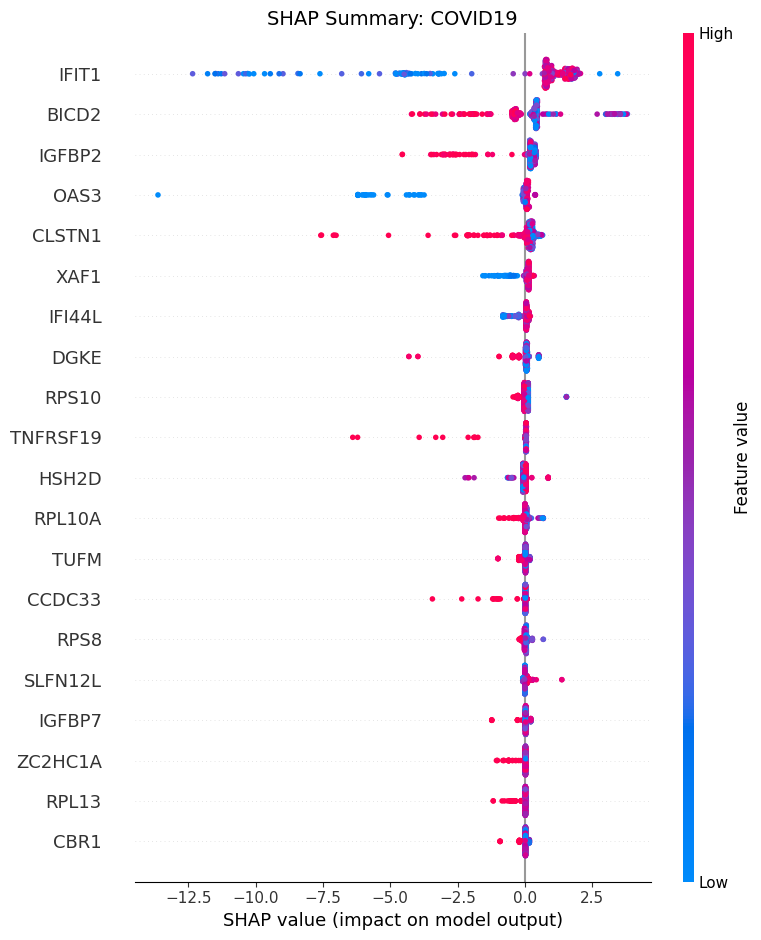

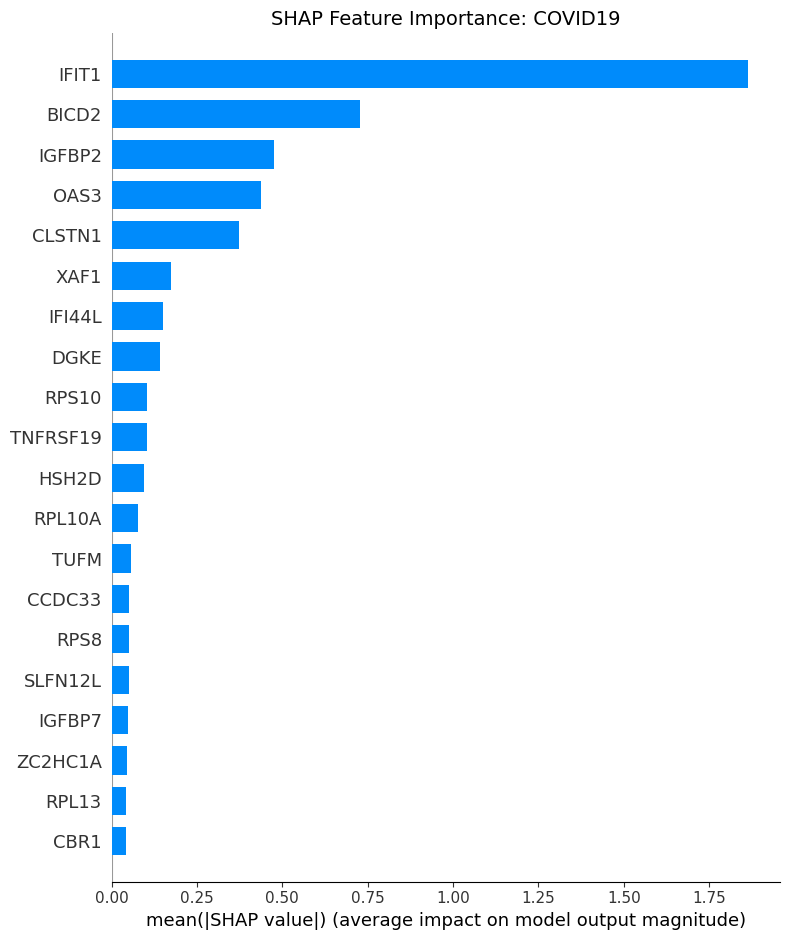


SHAP Summary: Diabetes


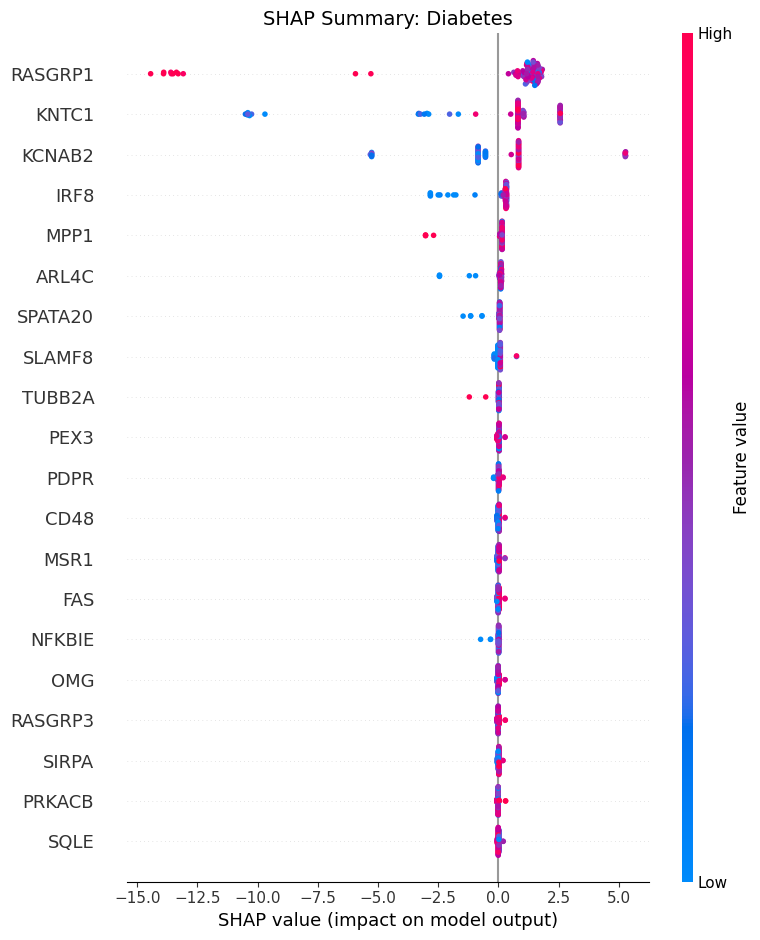

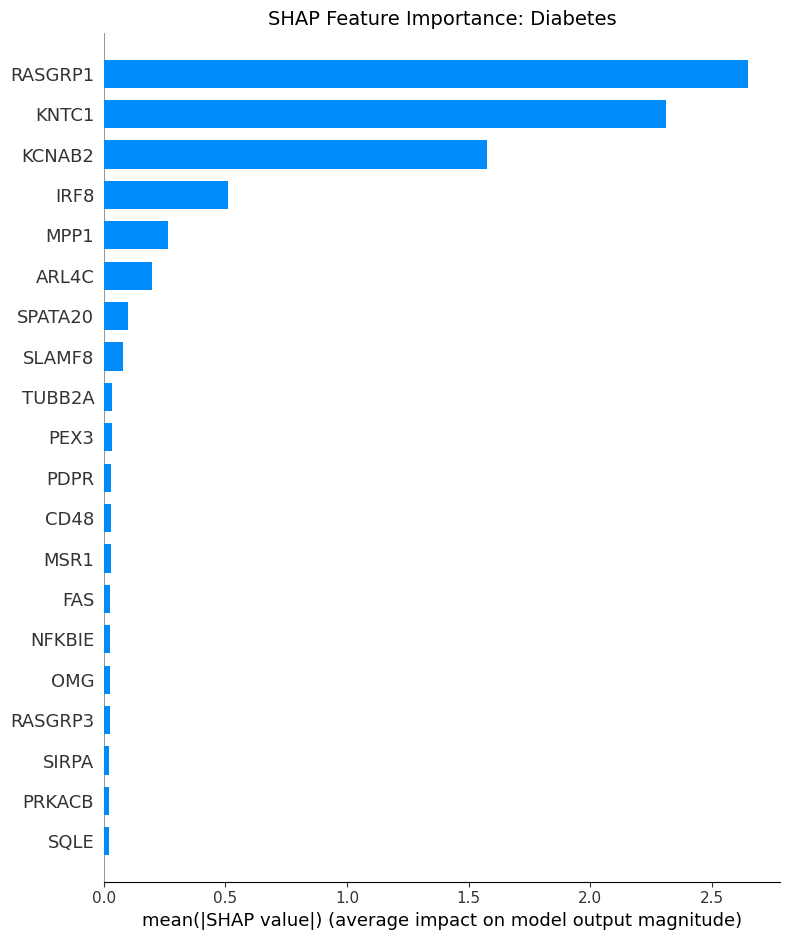


SHAP Summary: Sepsis


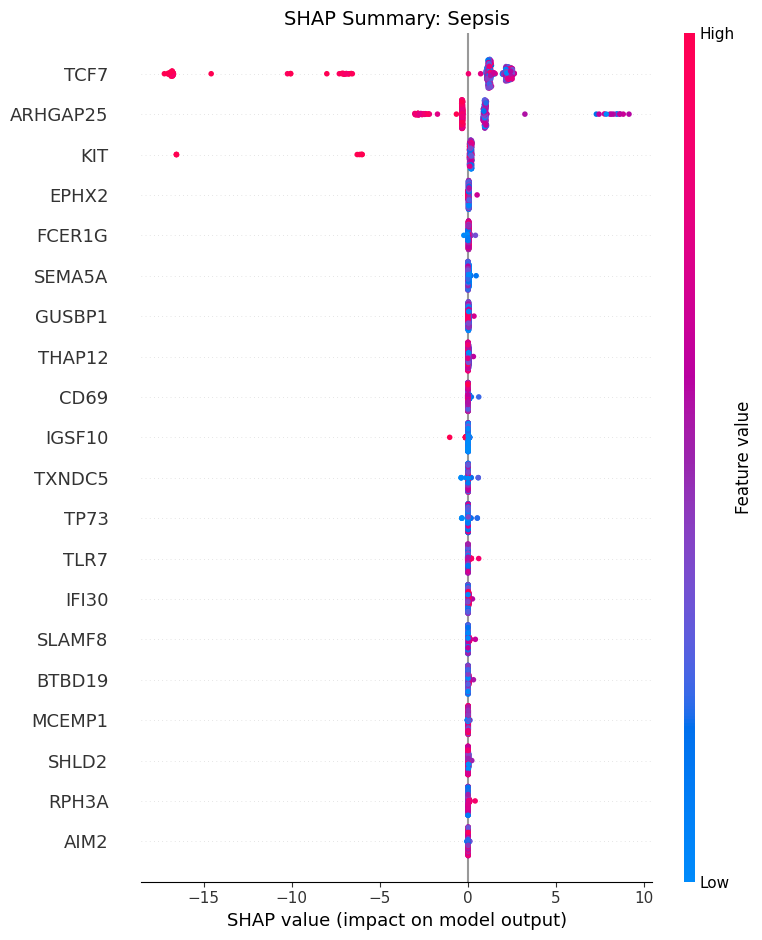

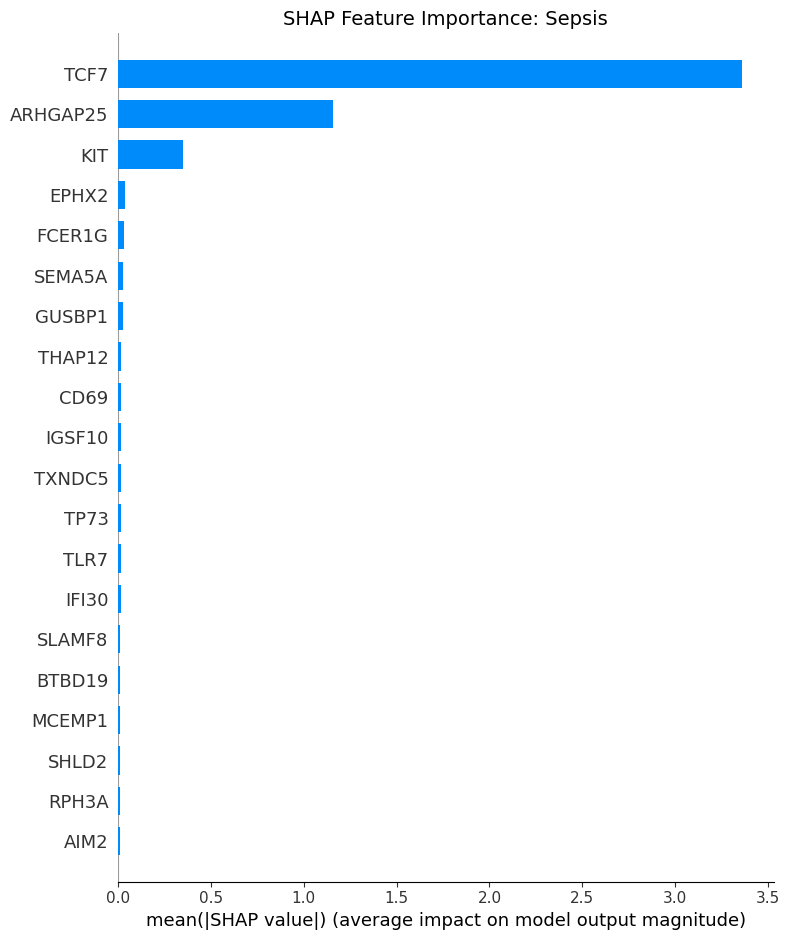


SHAP Summary: Dengue


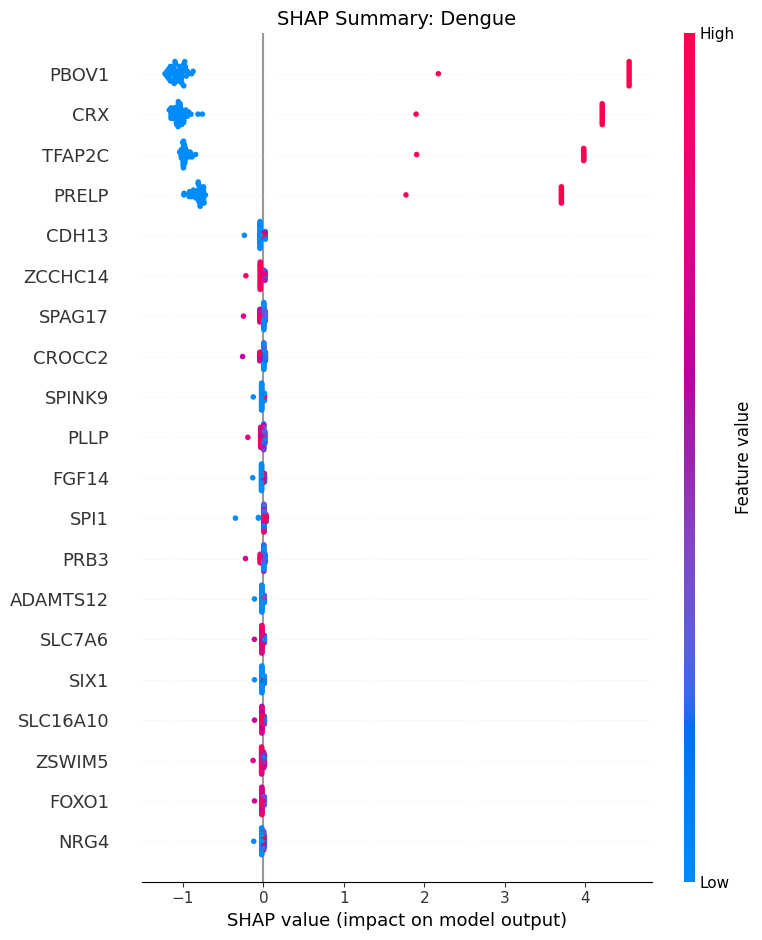

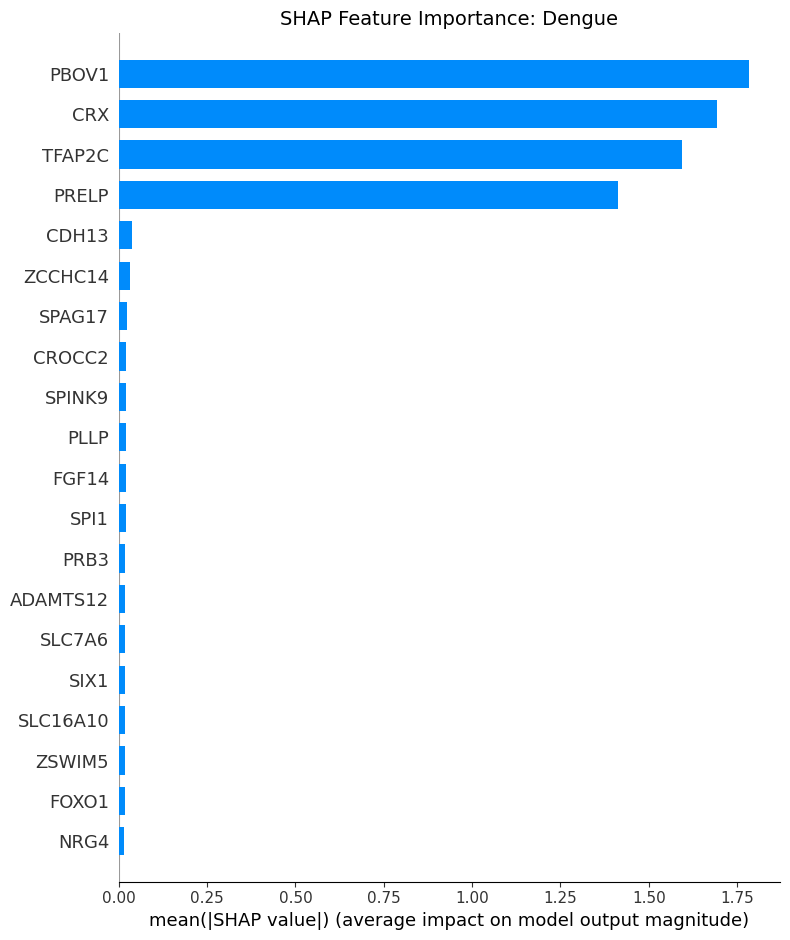

In [24]:
# ============================================================
# CELL 25: SHAP summary plots
# ============================================================
# This shows:
#   - Which genes have the highest SHAP values (most important)
#   - Red dots = high gene expression
#   - Blue dots = low gene expression
#   - Right side = pushes prediction toward CASE
#   - Left side = pushes prediction toward CONTROL

for disease_name, res in shap_results.items():
    print(f"\n{'='*60}")
    print(f"SHAP Summary: {disease_name}")
    print(f"{'='*60}")

    shap_df = res["shap_df"]
    X_scaled = res["X_scaled"]

    # Summary plot (beeswarm)
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_df.values,
        X_scaled,
        feature_names=shap_df.columns.tolist(),
        max_display=20,
        show=False
    )
    plt.title(f"SHAP Summary: {disease_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Bar plot (simpler)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_df.values,
        X_scaled,
        feature_names=shap_df.columns.tolist(),
        plot_type="bar",
        max_display=20,
        show=False
    )
    plt.title(f"SHAP Feature Importance: {disease_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [25]:
# ============================================================
# CELL 26: Sample-level biomarkers using SHAP
# ============================================================
# For EACH individual sample, find the top genes driving
# the model's prediction

def get_sample_biomarkers(shap_df, y, top_n=10):
    """
    For each sample, find genes with highest |SHAP| values.
    These are the genes most responsible for that sample's prediction.
    """
    results = []

    for sample_id in shap_df.index:
        sample_shap = shap_df.loc[sample_id]
        true_label = y.loc[sample_id] if sample_id in y.index else None

        # Sort by absolute SHAP value
        top_genes = sample_shap.abs().nlargest(top_n)

        for gene in top_genes.index:
            sv = sample_shap[gene]
            results.append({
                "sample_id": sample_id,
                "true_label": "Case" if true_label == 1 else "Control",
                "gene": gene,
                "shap_value": sv,
                "abs_shap": abs(sv),
                "direction": "Pushes→Case" if sv > 0 else "Pushes→Control"
            })

    return pd.DataFrame(results)


# Get sample-level biomarkers for each disease
sample_biomarkers = {}

for disease_name, res in shap_results.items():
    print(f"\n--- {disease_name} ---")

    sb = get_sample_biomarkers(res["shap_df"], res["y"], top_n=10)
    sample_biomarkers[disease_name] = sb

    # Show examples
    # Pick one Case and one Control sample
    cases = sb[sb["true_label"] == "Case"]["sample_id"].unique()
    ctrls = sb[sb["true_label"] == "Control"]["sample_id"].unique()

    if len(cases) > 0:
        example_case = cases[0]
        print(f"\n  Example CASE sample: {example_case}")
        case_genes = sb[sb["sample_id"] == example_case].head(5)
        for _, row in case_genes.iterrows():
            print(f"    {row['gene']:<15} SHAP={row['shap_value']:+.4f} {row['direction']}")

    if len(ctrls) > 0:
        example_ctrl = ctrls[0]
        print(f"\n  Example CONTROL sample: {example_ctrl}")
        ctrl_genes = sb[sb["sample_id"] == example_ctrl].head(5)
        for _, row in ctrl_genes.iterrows():
            print(f"    {row['gene']:<15} SHAP={row['shap_value']:+.4f} {row['direction']}")

print("\n✅ Sample-level biomarkers computed")


--- COVID19 ---

  Example CASE sample: GSE152075_GSM4602241
    IFIT1           SHAP=+0.7869 Pushes→Case
    BICD2           SHAP=+0.4150 Pushes→Case
    IGFBP2          SHAP=+0.3439 Pushes→Case
    CLSTN1          SHAP=+0.2702 Pushes→Case
    XAF1            SHAP=+0.1438 Pushes→Case

  Example CONTROL sample: GSE152075_GSM4602672
    IFIT1           SHAP=-5.3993 Pushes→Control
    DGKE            SHAP=-3.9740 Pushes→Control
    CLSTN1          SHAP=-3.5958 Pushes→Control
    IGFBP2          SHAP=-2.5639 Pushes→Control
    ZC2HC1A         SHAP=-1.0267 Pushes→Control

--- Diabetes ---

  Example CASE sample: GSE164416_GSM5009229
    KNTC1           SHAP=+2.5683 Pushes→Case
    RASGRP1         SHAP=+1.3322 Pushes→Case
    KCNAB2          SHAP=-0.8398 Pushes→Control
    IRF8            SHAP=+0.2645 Pushes→Case
    MPP1            SHAP=+0.1547 Pushes→Case

  Example CONTROL sample: GSE164416_GSM5009234
    RASGRP1         SHAP=-13.3711 Pushes→Control
    IRF8            SHAP=-2.4994 Push


WATERFALL PLOTS: COVID19

  Sample: GSE152075_GSM4602241 (True label: Case)


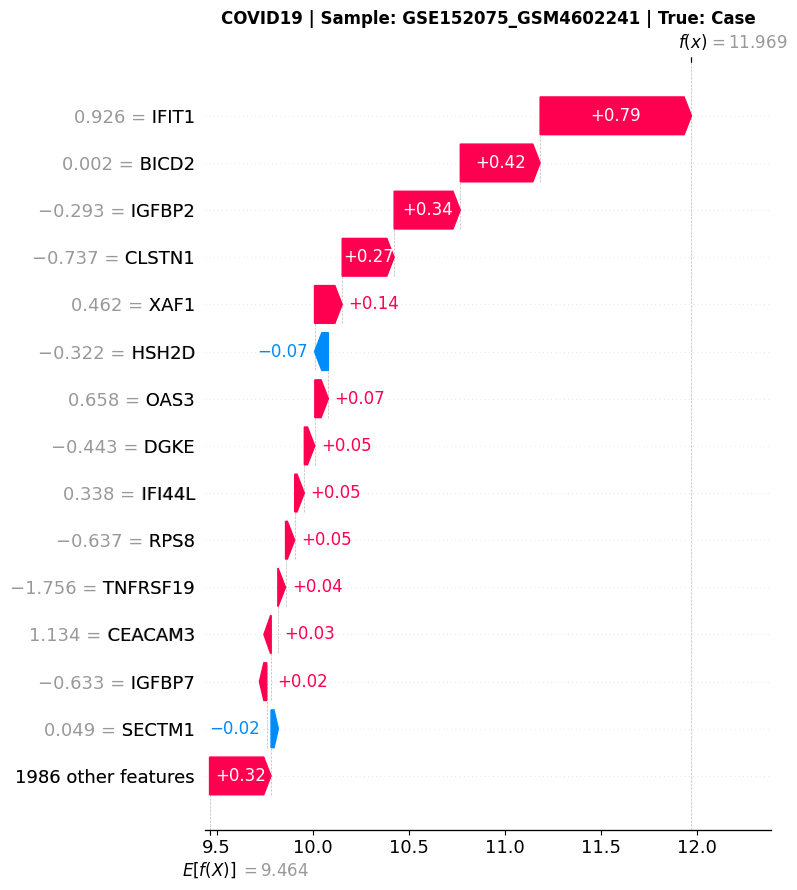


  Sample: GSE152075_GSM4602672 (True label: Control)


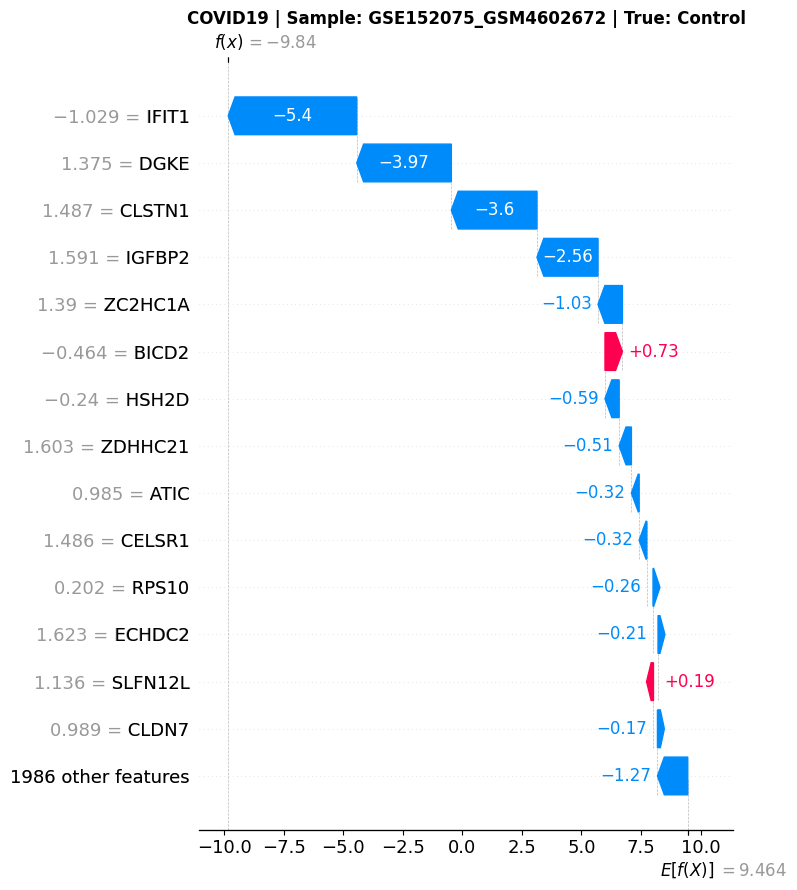


WATERFALL PLOTS: Diabetes

  Sample: GSE164416_GSM5009229 (True label: Case)


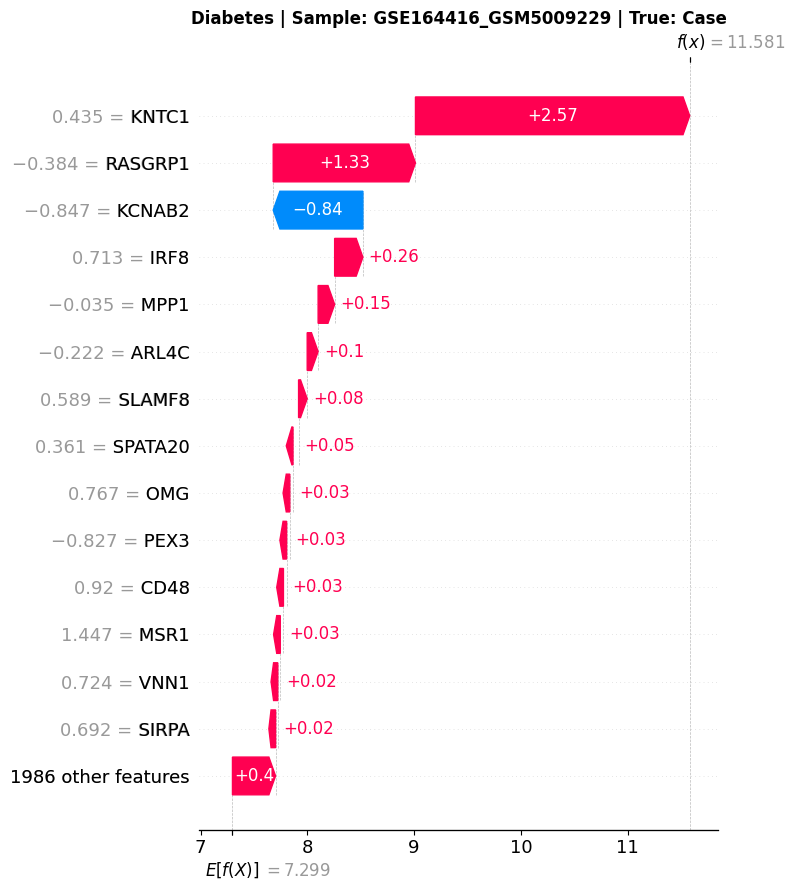


  Sample: GSE164416_GSM5009234 (True label: Control)


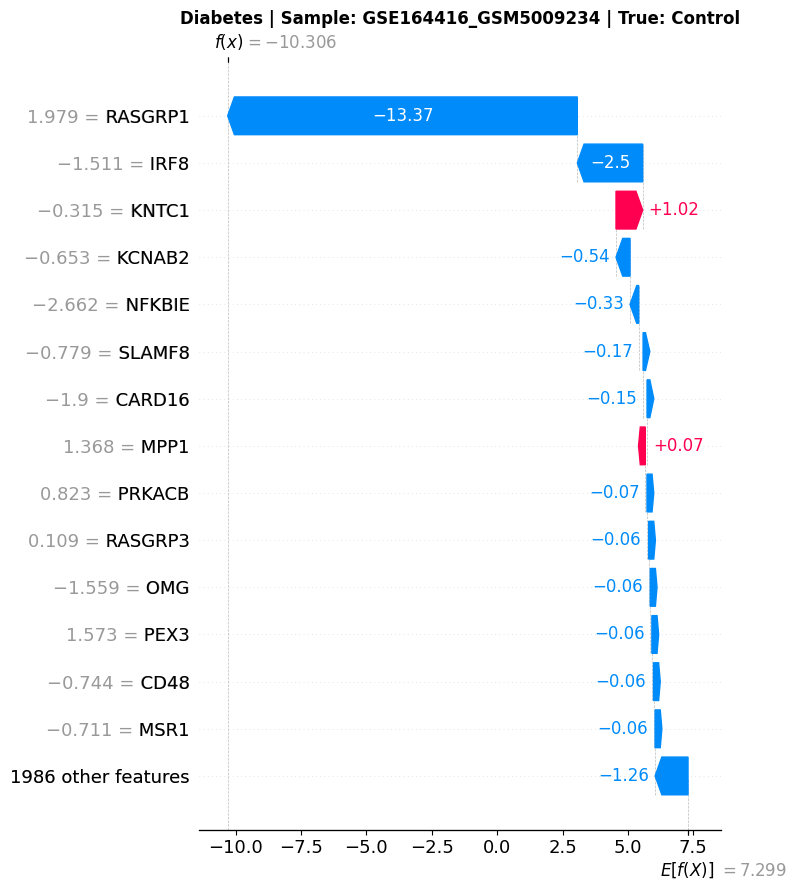


WATERFALL PLOTS: Sepsis

  Sample: GSE185263_GSM5608946 (True label: Case)


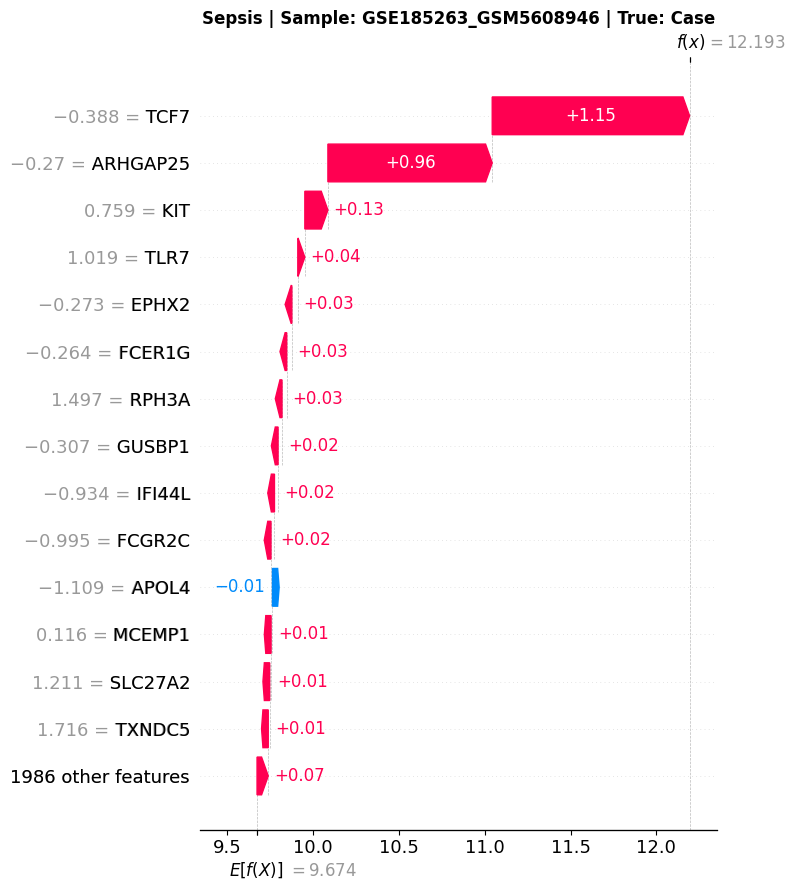


  Sample: GSE185263_GSM5609212 (True label: Control)


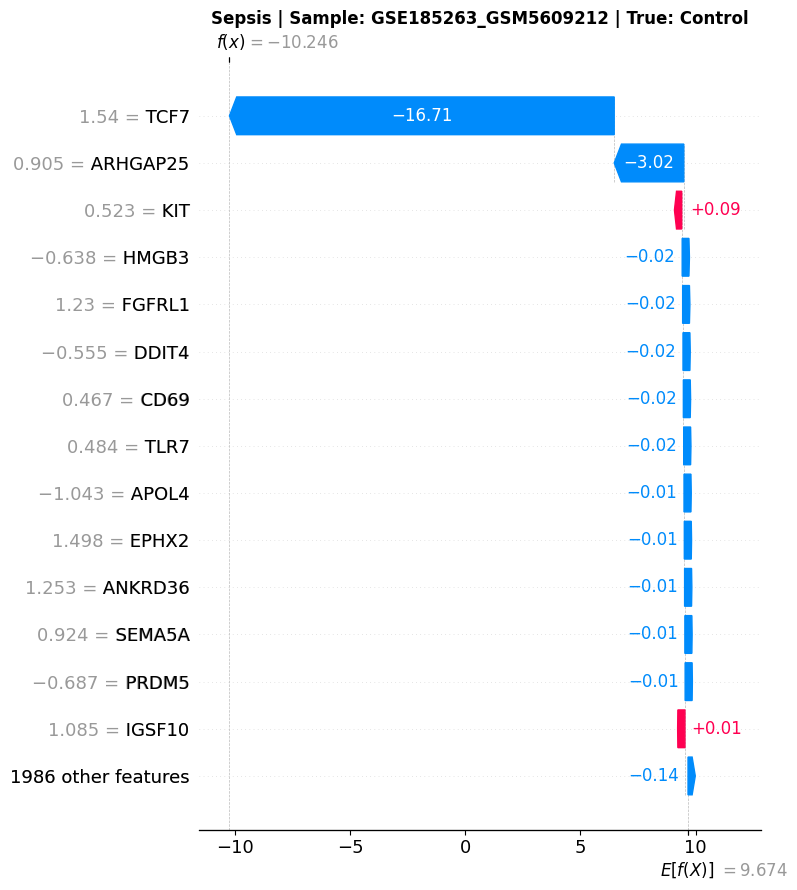


WATERFALL PLOTS: Dengue

  Sample: GSE215835_GSM6642079 (True label: Case)


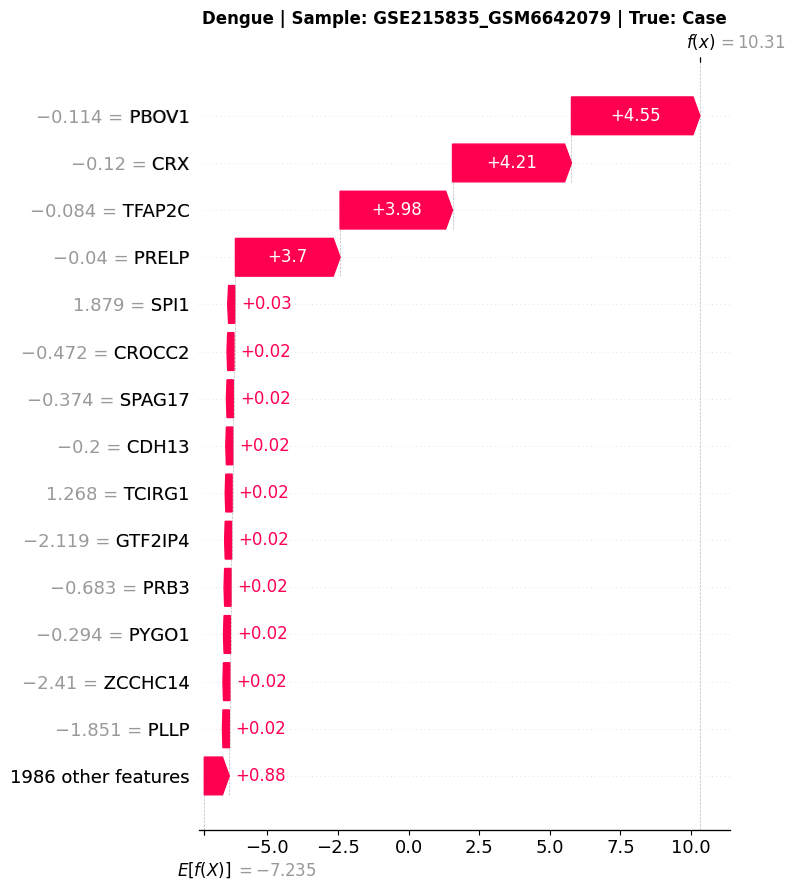


  Sample: GSE185263_GSM5609212 (True label: Control)


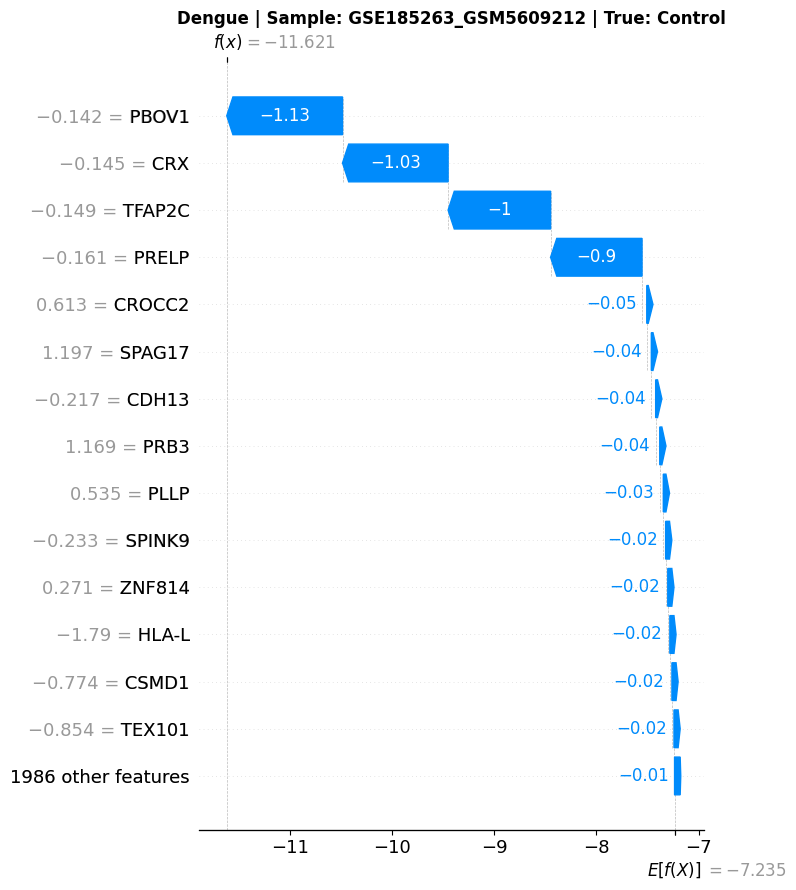

In [26]:
# ============================================================
# CELL 27: SHAP waterfall plot for individual patients
# ============================================================
# Shows exactly how each gene contributes to the prediction
# for ONE specific patient

def plot_sample_waterfall(shap_df, X_scaled, y, sample_idx,
                          disease_name, explainer):
    """
    Waterfall plot for a single sample.
    Shows how each gene pushes the prediction up or down.
    """
    sample_id = shap_df.index[sample_idx]
    true_label = "Case" if y.iloc[sample_idx] == 1 else "Control"

    print(f"\n  Sample: {sample_id} (True label: {true_label})")

    # Create SHAP Explanation object
    sv = shap_df.iloc[sample_idx].values
    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        base_value = base_value[1] if len(base_value) > 1 else base_value[0]

    explanation = shap.Explanation(
        values=sv,
        base_values=base_value,
        data=X_scaled.iloc[sample_idx].values,
        feature_names=shap_df.columns.tolist()
    )

    plt.figure(figsize=(10, 8))
    shap.waterfall_plot(explanation, max_display=15, show=False)
    plt.title(f"{disease_name} | Sample: {sample_id} | True: {true_label}",
              fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Plot waterfall for first Case and first Control in each disease
for disease_name, res in shap_results.items():
    print(f"\n{'='*60}")
    print(f"WATERFALL PLOTS: {disease_name}")
    print(f"{'='*60}")

    y = res["y"]
    shap_df = res["shap_df"]
    X_scaled = res["X_scaled"]
    explainer = res["explainer"]

    # First case sample
    case_indices = np.where(y.values == 1)[0]
    if len(case_indices) > 0:
        plot_sample_waterfall(shap_df, X_scaled, y,
                              case_indices[0], disease_name, explainer)

    # First control sample
    ctrl_indices = np.where(y.values == 0)[0]
    if len(ctrl_indices) > 0:
        plot_sample_waterfall(shap_df, X_scaled, y,
                              ctrl_indices[0], disease_name, explainer)

In [27]:
# ============================================================
# CELL 28: Z-score outlier analysis per sample
# ============================================================
# For each sample, find genes that are abnormally high or low
# compared to the control group
# No ML needed — purely statistical

def find_sample_outlier_genes(X, y, z_threshold=2.5, top_n=20):
    """
    For each CASE sample:
      - Compare its expression to the CONTROL distribution
      - Find genes where the sample is > z_threshold SDs away
      - These are sample-specific abnormal genes
    """
    ctrl_mask = y == 0
    case_mask = y == 1

    X_ctrl = X.loc[ctrl_mask]
    X_case = X.loc[case_mask]

    # Control distribution per gene
    ctrl_mean = X_ctrl.mean(axis=0)
    ctrl_std = X_ctrl.std(axis=0).replace(0, 1)

    results = []

    for sample_id in X_case.index:
        sample_expr = X_case.loc[sample_id]

        # Z-score relative to controls
        z_scores = (sample_expr - ctrl_mean) / ctrl_std

        # Find outlier genes
        outliers = z_scores.abs().nlargest(top_n)

        for gene in outliers.index:
            z = z_scores[gene]
            results.append({
                "sample_id": sample_id,
                "gene": gene,
                "z_score": z,
                "abs_z": abs(z),
                "expression": sample_expr[gene],
                "ctrl_mean": ctrl_mean[gene],
                "ctrl_std": ctrl_std[gene],
                "direction": "UP" if z > 0 else "DOWN",
                "is_outlier": abs(z) > z_threshold
            })

    return pd.DataFrame(results)


# Run for each disease
outlier_results = {}

for disease_name, task in DISEASE_TASKS.items():
    if disease_name not in all_results:
        continue

    print(f"\n--- Outlier Analysis: {disease_name} ---")

    outlier_df = find_sample_outlier_genes(
        task["X"], task["y"],
        z_threshold=2.5,
        top_n=15
    )

    n_samples = outlier_df["sample_id"].nunique()
    n_outlier_genes = outlier_df[outlier_df["is_outlier"]]["gene"].nunique()

    print(f"  Case samples analyzed: {n_samples}")
    print(f"  Unique outlier genes (|z|>2.5): {n_outlier_genes}")

    # Most frequently abnormal genes across patients
    freq = (outlier_df[outlier_df["is_outlier"]]
            .groupby("gene")
            .size()
            .sort_values(ascending=False)
            .head(10))

    print(f"\n  Most frequently abnormal genes:")
    for gene, count in freq.items():
        pct = count / n_samples * 100
        print(f"    {gene:<15} abnormal in {count}/{n_samples} patients ({pct:.0f}%)")

    outlier_results[disease_name] = outlier_df

print("\n✅ Outlier analysis complete")


--- Outlier Analysis: COVID19 ---
  Case samples analyzed: 430
  Unique outlier genes (|z|>2.5): 1157

  Most frequently abnormal genes:
    PRLR            abnormal in 75/430 patients (17%)
    SIGLEC12        abnormal in 72/430 patients (17%)
    WNT7A           abnormal in 71/430 patients (17%)
    GRIN2D          abnormal in 55/430 patients (13%)
    EDNRB           abnormal in 52/430 patients (12%)
    ZNF521          abnormal in 47/430 patients (11%)
    MS4A4A          abnormal in 45/430 patients (10%)
    TOMM20P2        abnormal in 44/430 patients (10%)
    OTOGL           abnormal in 43/430 patients (10%)
    FFAR3           abnormal in 39/430 patients (9%)

--- Outlier Analysis: Diabetes ---
  Case samples analyzed: 74
  Unique outlier genes (|z|>2.5): 316

  Most frequently abnormal genes:
    ALDH3A1         abnormal in 23/74 patients (31%)
    FCRL1           abnormal in 23/74 patients (31%)
    IGHV5-51        abnormal in 20/74 patients (27%)
    IGLV4-69        abnorma

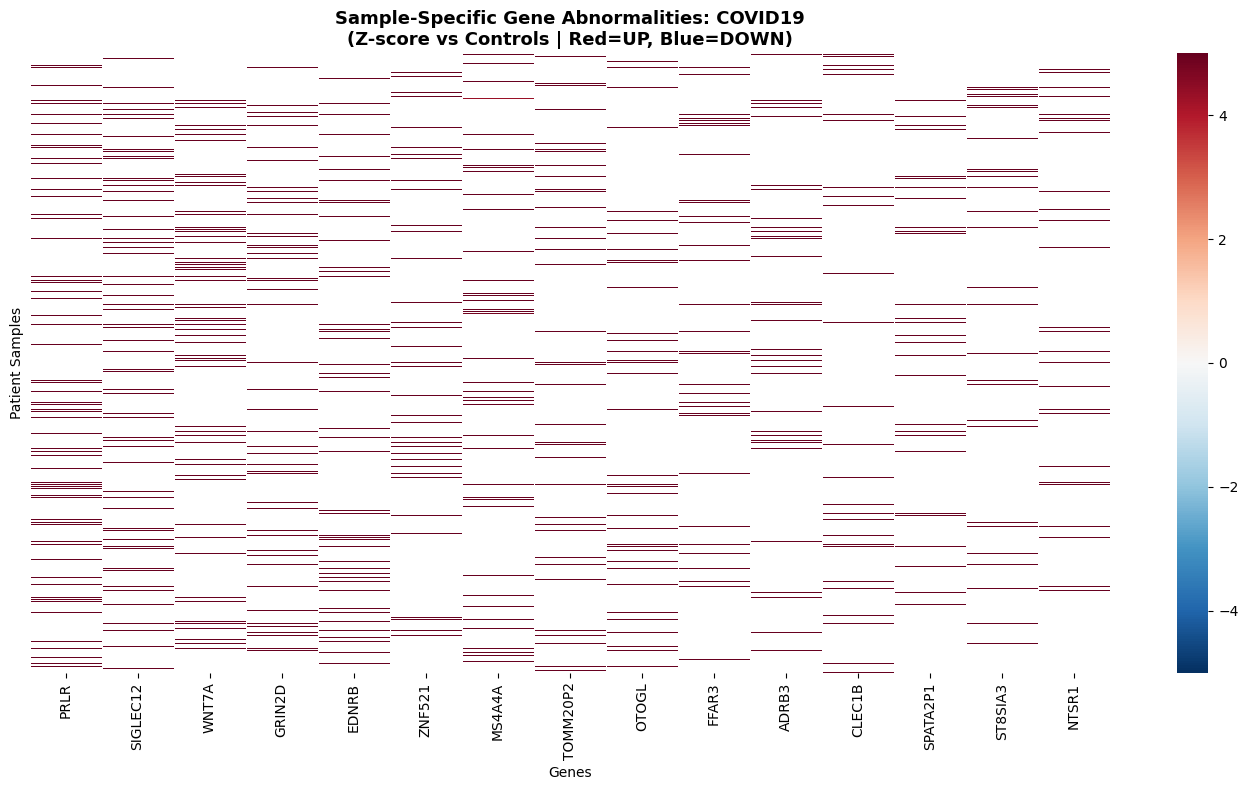

  Showing 340 samples × 15 genes


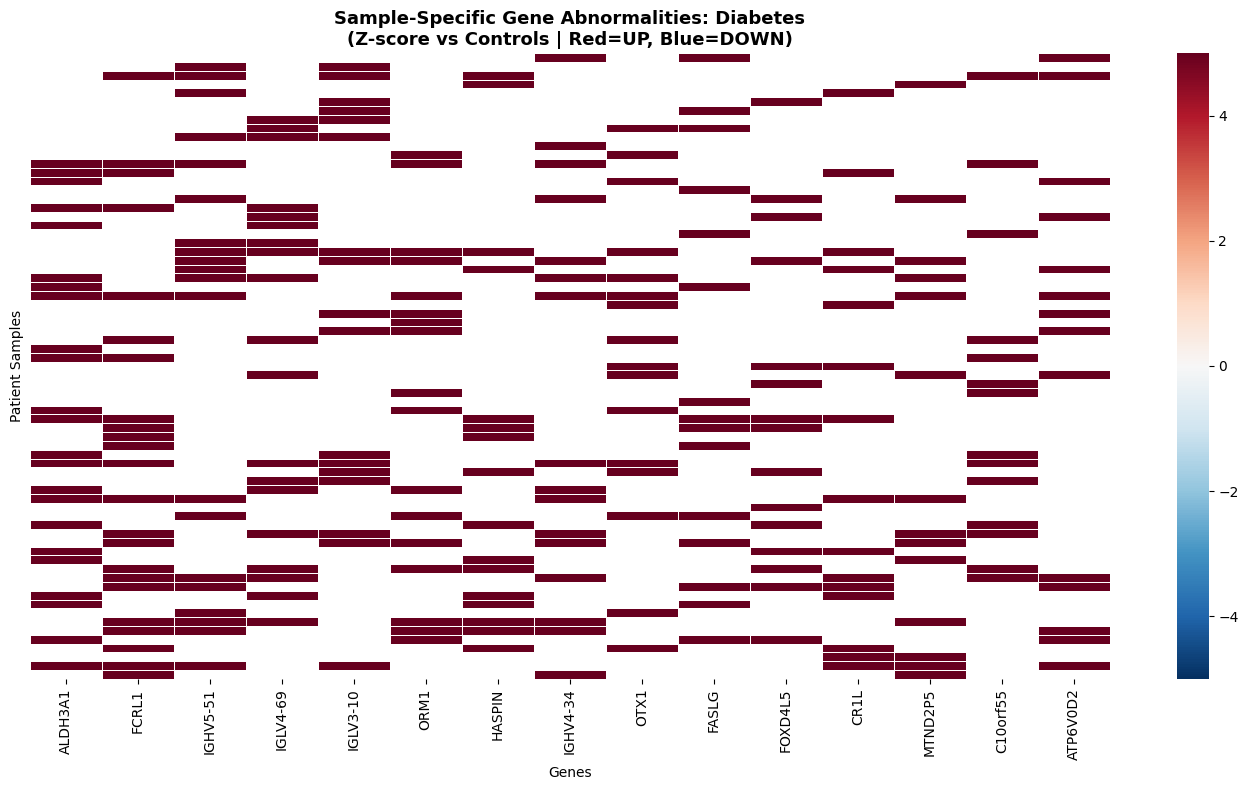

  Showing 71 samples × 15 genes


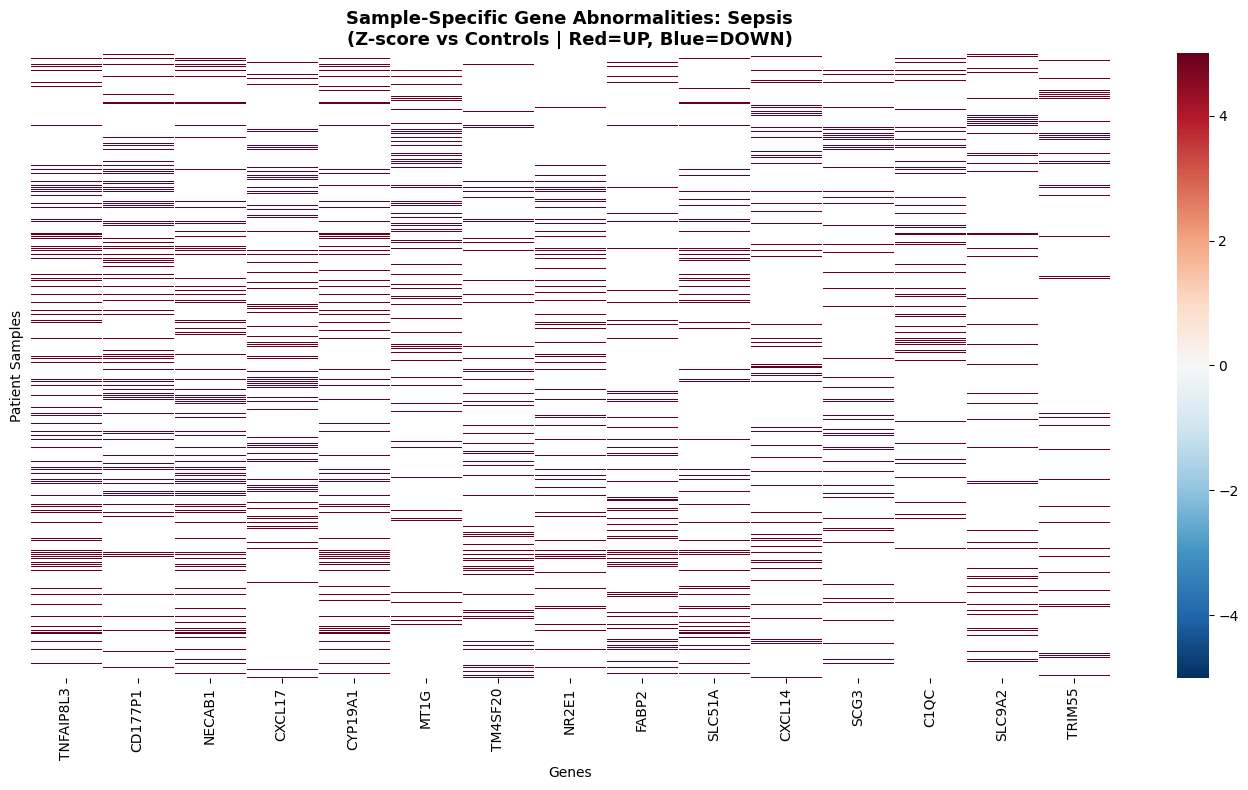

  Showing 310 samples × 15 genes


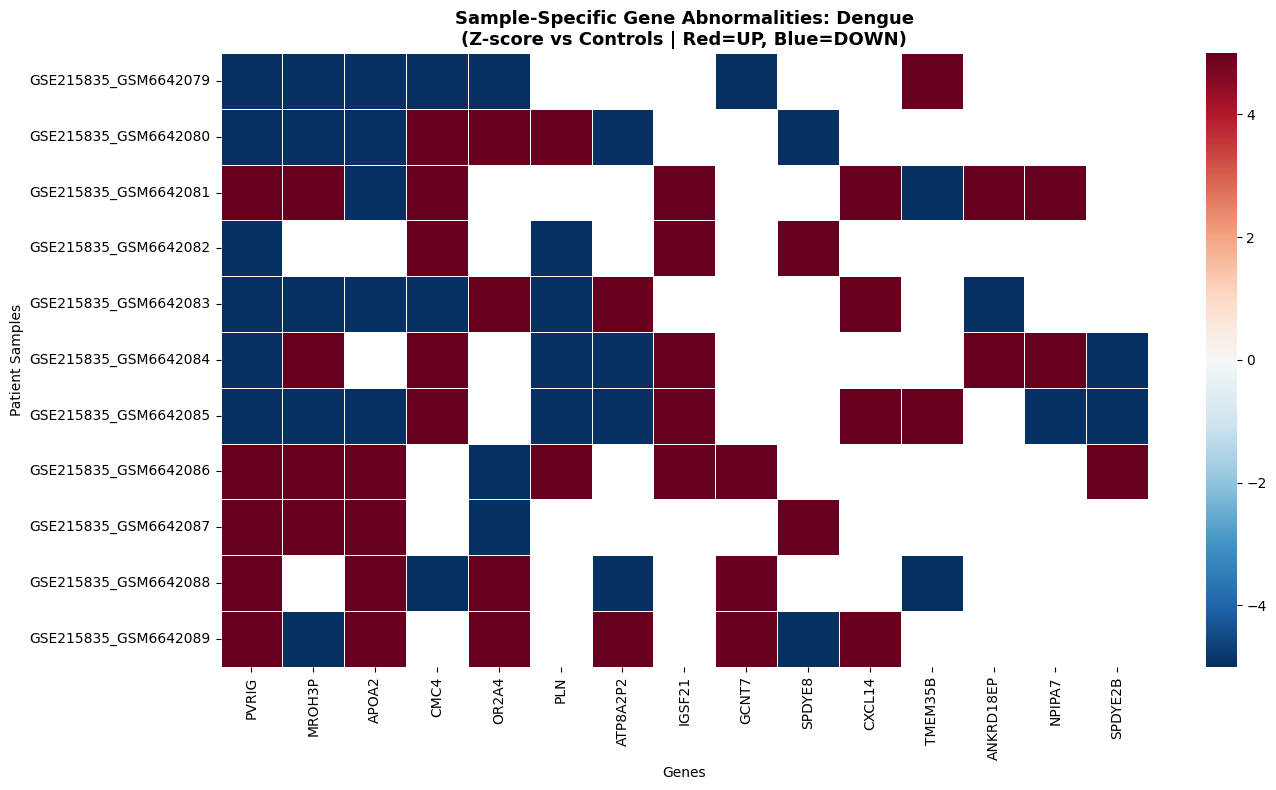

  Showing 11 samples × 15 genes


In [28]:
# ============================================================
# CELL 29: Heatmap showing sample-specific outlier genes
# ============================================================

def plot_outlier_heatmap(outlier_df, disease_name, top_genes=15, figsize=(14, 8)):
    """
    Heatmap showing Z-scores of top outlier genes per sample.
    Each cell = how abnormal that gene is in that patient.
    """
    if outlier_df.empty:
        print(f"No outliers for {disease_name}")
        return

    # Get most frequently abnormal genes
    freq = (outlier_df[outlier_df["is_outlier"]]
            .groupby("gene").size()
            .sort_values(ascending=False)
            .head(top_genes))

    if len(freq) == 0:
        print(f"No outlier genes for {disease_name}")
        return

    top_gene_list = freq.index.tolist()

    # Pivot: samples × genes with z-scores
    pivot = outlier_df[outlier_df["gene"].isin(top_gene_list)].pivot_table(
        index="sample_id",
        columns="gene",
        values="z_score",
        aggfunc="first"
    )

    # Reorder columns
    pivot = pivot[top_gene_list]

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        pivot,
        cmap="RdBu_r",
        center=0,
        vmin=-5, vmax=5,
        xticklabels=True,
        yticklabels=True if pivot.shape[0] <= 50 else False,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(
        f"Sample-Specific Gene Abnormalities: {disease_name}\n"
        f"(Z-score vs Controls | Red=UP, Blue=DOWN)",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Genes")
    ax.set_ylabel("Patient Samples")

    plt.tight_layout()
    plt.show()

    print(f"  Showing {pivot.shape[0]} samples × {pivot.shape[1]} genes")


# Plot for each disease
for disease_name, outlier_df in outlier_results.items():
    plot_outlier_heatmap(outlier_df, disease_name)

In [29]:
# ============================================================
# CELL 30: Save all condition-level and sample-level results
# ============================================================

RESULTS_DIR = os.path.join(BASE_PATH, "biomarker_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# 1. Condition-level biomarkers
for task_name, merged in condition_biomarkers.items():
    safe = task_name.replace("/", "_").replace(" ", "_")
    merged.to_csv(os.path.join(RESULTS_DIR, f"condition_{safe}_ranking.csv"), index=False)

    if "is_strong_biomarker" in merged.columns:
        strong = merged[merged["is_strong_biomarker"]]
        if len(strong) > 0:
            strong.to_csv(os.path.join(RESULTS_DIR, f"condition_{safe}_strong.csv"), index=False)

# 2. SHAP sample-level biomarkers
for disease, sb in sample_biomarkers.items():
    safe = disease.replace("/", "_").replace(" ", "_")
    sb.to_csv(os.path.join(RESULTS_DIR, f"shap_sample_{safe}.csv"), index=False)

# 3. SHAP values (full matrix)
for disease, res in shap_results.items():
    safe = disease.replace("/", "_").replace(" ", "_")
    res["shap_df"].to_csv(os.path.join(RESULTS_DIR, f"shap_values_{safe}.csv"))

# 4. Outlier analysis
for disease, outlier_df in outlier_results.items():
    safe = disease.replace("/", "_").replace(" ", "_")
    outlier_df.to_csv(os.path.join(RESULTS_DIR, f"outlier_genes_{safe}.csv"), index=False)

# 5. Summary table
summary_rows = []
for task_name in condition_biomarkers:
    merged = condition_biomarkers[task_name]
    n_strong = merged["is_strong_biomarker"].sum() if "is_strong_biomarker" in merged.columns else 0

    res = condition_results.get(task_name, {})
    summary_rows.append({
        "Comparison": task_name,
        "Samples": res.get("n_samples", 0),
        "AUC": f"{res.get('mean_auc', 0):.4f}",
        "Strong_Biomarkers": n_strong,
        "Top_Gene": merged.iloc[0]["gene"] if len(merged) > 0 else ""
    })

pd.DataFrame(summary_rows).to_csv(
    os.path.join(RESULTS_DIR, "condition_level_summary.csv"), index=False
)

print("All results saved ✅")
print(f"Folder: {RESULTS_DIR}\n")
for f in sorted(os.listdir(RESULTS_DIR)):
    sz = os.path.getsize(os.path.join(RESULTS_DIR, f))
    print(f"  📄 {f} ({sz/1024:.1f} KB)")

All results saved ✅
Folder: /content/drive/MyDrive/compendium_output/biomarker_results

  📄 COVID19_DE_results.csv (2396.8 KB)
  📄 COVID19_full_ranking.csv (665.7 KB)
  📄 COVID19_specific_genes.csv (0.2 KB)
  📄 COVID19_strong_biomarkers.csv (9.8 KB)
  📄 COVID19_top50.csv (14.1 KB)
  📄 Dengue_DE_results.csv (2377.9 KB)
  📄 Dengue_full_ranking.csv (631.3 KB)
  📄 Dengue_specific_genes.csv (0.0 KB)
  📄 Dengue_strong_biomarkers.csv (1.6 KB)
  📄 Dengue_top50.csv (13.5 KB)
  📄 Diabetes_DE_results.csv (2371.7 KB)
  📄 Diabetes_full_ranking.csv (639.7 KB)
  📄 Diabetes_specific_genes.csv (0.1 KB)
  📄 Diabetes_strong_biomarkers.csv (2.7 KB)
  📄 Diabetes_top50.csv (13.3 KB)
  📄 Sepsis_DE_results.csv (2416.6 KB)
  📄 Sepsis_full_ranking.csv (646.1 KB)
  📄 Sepsis_specific_genes.csv (0.2 KB)
  📄 Sepsis_strong_biomarkers.csv (9.1 KB)
  📄 Sepsis_top50.csv (13.8 KB)
  📄 condition_COVID19_Pos_vs_Neg_ranking.csv (665.7 KB)
  📄 condition_COVID19_Pos_vs_Neg_strong.csv (9.8 KB)
  📄 condition_Dengue_DF_vs_DHF_r